# NB06 – Räumliche Analyse: Batteriestandort & Netzentlastung
### CAS Information Engineering – Scripting Project (Kür)
**Gruppe:** SC26_Gruppe_2 | **Datum:** März–Mai 2026

---
Geodaten-Analyse: Battery Value Index (BVI), Zonenbilanzen, Standortoptimierung.  
Liest aus `data/raw/` (BFE GPKG) und `data/intermediate/`.

---
| [← NB05 Business Strategy](05_Business_Strategy.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB07 Cross-Border](07_Cross_Border.ipynb) |
|:---|:---:|---:|


In [1]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import subprocess, sys
for imp, pkg in [('geopandas','geopandas'),('pandas','pandas'),
                 ('numpy','numpy'),('matplotlib','matplotlib'),
                 ('requests','requests'),('scipy','scipy')]:
    try: __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import os, warnings, io, zipfile, json as _json
import requests, numpy as np, pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib import cm
from shapely.geometry import Point, Polygon
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')

# ── config.json laden ───────────────────────────────────────────────────────
# Schalter NIE direkt hier setzen — immer in config.json anpassen.
with open('config.json') as _cfg_f: CFG = _json.load(_cfg_f)

# Aliases (nur lesend)
MODE         = CFG['mode']
FORCE_RELOAD = CFG['force_reload']
BASE_PEAK_GW = CFG['szenarien']['ch_spitzenlast_gw']
GZ_MODE      = CFG['szenarien']['gleichzeitigkeit_aktiv']
GZ_RATE      = CFG['szenarien']['optionen'][GZ_MODE]['rate']

DATA_DIR   = os.path.join(MODE, 'raw')
INTER_DIR  = os.path.join(MODE, 'intermediate')
SZ_AKTIV   = GZ_MODE
CHARTS_DIR = os.path.join('output', 'charts', SZ_AKTIV)
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
_viz       = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK    = _viz.get('bg_dark',    '#0d1117')
BG_PANEL   = _viz.get('bg_panel',   '#141414')
C_PRICE    = _viz.get('c_price',    '#FFA726')
C_LOAD     = _viz.get('c_load',     '#66BB6A')
SEG_COLORS = _viz.get('seg_colors', ['#42A5F5','#66BB6A','#FFA726','#EF5350'])
print(f'config.json | MODE={MODE} | GZ={GZ_MODE} ({GZ_RATE*100:.0f}%) | BASE_PEAK={BASE_PEAK_GW}GW')

print(f'GeoPandas: {gpd.__version__}')
print(f'Datenordner: {os.path.abspath(DATA_DIR)}')

DATAINDEX = 'dataindex.csv'

def log_dataindex(filename, source_url, local_path, data_type,
                  rows=None, size_kb=None, status='active', note=''):
    import datetime
    ts = datetime.datetime.utcnow().isoformat(timespec='seconds') + 'Z'
    if os.path.exists(DATAINDEX):
        df_idx = pd.read_csv(DATAINDEX)
        mask = (df_idx['filename']==filename) & (df_idx['status']=='active')
        if mask.any():
            df_idx.loc[mask,'status'] = 'superseded'
            df_idx.loc[mask,'superseded_at'] = ts
    else:
        df_idx = pd.DataFrame(columns=['timestamp','filename','source_url',
                              'local_path','data_type','rows','size_kb',
                              'status','superseded_at','note'])
    row = {'timestamp':ts,'filename':filename,'source_url':source_url,
           'local_path':local_path,'data_type':data_type,'rows':rows,
           'size_kb':round(size_kb,1) if size_kb else None,
           'status':status,'superseded_at':'','note':note}
    pd.concat([df_idx,pd.DataFrame([row])],ignore_index=True).to_csv(DATAINDEX,index=False)
    print(f'  dataindex: {filename} [{status}]')

# ══════════════════════════════════════════════════════════════════════════════
# FORCE_RELOAD
# ══════════════════════════════════════════════════════════════════════════════
# FORCE_RELOAD alias → aus config.json (Setup-Zelle)
def needs_download(filepath, min_kb, ds_key):
    if FORCE_RELOAD.get(ds_key, False):
        print(f'  FORCE_RELOAD={ds_key} → neu laden')
        return True
    if not os.path.exists(filepath): return True
    if os.path.getsize(filepath) < min_kb * 1024: return True
    return False


config.json | MODE=data | GZ=realistisch (40%) | BASE_PEAK=10.5GW
GeoPandas: 1.1.3
Datenordner: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\data\raw


**Setup NB5.** Liest aus `data/raw/` (GPKG, Kantongrenzen) und `data/intermediate/` (Zonenbilanzen). `geopandas` für Geodaten, `scipy` für räumliche Distanzberechnungen.

---
## 1. Daten laden

### 1.1 BFE Elektrizitätsproduktionsanlagen *(Download hier — erstes NB das diesen Datensatz benötigt)*

**Quelle:** BFE / Pronovo AG | **Format:** GeoPackage EPSG:2056 | **Update:** monatlich

#### Kategorie-System (offiziell)

| Spalte | Verwendung | Codes |
|--------|-----------|-------|
| `MainCategory` | Zu grob (4 Werte) – maincat_2 = Solar+Wind+Biomasse+Geothermie zusammen | maincat_1–4 |
| **`SubCategory`** | **Verwenden** – direkte 1:1-Zuordnung | subcat_1–10 |
| `PlantCategory` | Technischer Anlagentyp | plantcat_1–13 |

#### SubCategory-Codes (Quelle: SubCategoryCatalogue.csv aus BFE CSV-Export)

| Code | Energieträger | Code | Energieträger |
|------|--------------|------|--------------|
| subcat_1 | Wasserkraft | subcat_6 | Kernenergie |
| subcat_2 | Photovoltaik | subcat_7 | Erdöl |
| subcat_3 | Windenergie | subcat_8 | Erdgas |
| subcat_4 | Biomasse | subcat_9 | Kohle |
| subcat_5 | Geothermie | subcat_10 | Abfälle |


In [2]:
# ── BFE Produktionsanlagen laden ─────────────────────────────────────────────
BFE_FILE = os.path.join(DATA_DIR, 'bfe_produktionsanlagen.gpkg')
BFE_URL  = ('https://data.geo.admin.ch/ch.bfe.elektrizitaetsproduktionsanlagen'
             '/gpkg/2056/ch.bfe.elektrizitaetsproduktionsanlagen.gpkg')

if not os.path.exists(BFE_FILE) or os.path.getsize(BFE_FILE) < 100_000:
    print('⬇️  Lade BFE GPKG...')
    r = requests.get(BFE_URL, stream=True, timeout=300)
    total = int(r.headers.get('Content-Length', 0))
    done = 0
    with open(BFE_FILE, 'wb') as f:
        for chunk in r.iter_content(1024*512):
            f.write(chunk); done += len(chunk)
            if total: print(f'\r  {done/1024**2:.1f} MB', end='')
    print()
else:
    print(f'ℹ️  BFE-Datei vorhanden ({os.path.getsize(BFE_FILE)/1024**2:.0f} MB)')

layer   = gpd.list_layers(BFE_FILE)['name'].iloc[0]
gdf_raw = gpd.read_file(BFE_FILE, layer=layer)

# Koordinaten → WGS84 konvertieren
gdf_plants = gdf_raw.to_crs(epsg=4326).copy()

print(f'\nGeladen: {len(gdf_plants):,} Anlagen')
print(f'Spalten: {list(gdf_plants.columns)}')


ℹ️  BFE-Datei vorhanden (56 MB)



Geladen: 322,329 Anlagen
Spalten: ['xtf_id', 'Address', 'PostCode', 'Municipality', 'Canton', 'BeginningOfOperation', 'InitialPower', 'TotalPower', 'MainCategory', 'SubCategory', 'PlantCategory', 'geometry']


In [3]:
# ── Verifikation: BFE GeoDataFrame ──────────────────────────────────────────
print(f'Shape  : {gdf_plants.shape}')
print(f'CRS    : {gdf_plants.crs}')
print(f'Nulls  : {gdf_plants.isnull().sum().sum()}')
print(f'Typen  : {gdf_plants.geometry.geom_type.value_counts().to_dict()}')
gdf_plants[['SubCategory','TotalPower','BeginningOfOperation','Canton']].head(3)


Shape  : (322329, 12)
CRS    : EPSG:4326
Nulls  : 35563
Typen  : {'Point': 286766}


,SubCategory,TotalPower,BeginningOfOperation,Canton
0,subcat_2,18.809999,2009-05-05,BL
1,subcat_2,5.800000,2011-10-28,AG
2,subcat_2,3.000000,2008-10-07,BE


**BFE GeoPackage laden.** 322k Anlagen, ~56 MB. Layer-Name wird automatisch erkannt. Koordinaten werden von EPSG:2056 (Schweizer Projektionskoordinaten) nach WGS84 (Lat/Lon) konvertiert.

In [4]:
# ── Spalten-Mapping ──────────────────────────────────────────────────────────
def find_col(df, *kws):
    for kw in kws:
        for c in df.columns:
            if kw.lower() in c.lower(): return c
    return None

COL = {
    'subcat'  : find_col(gdf_plants,'subcat','subcategor'),
    'maincat' : find_col(gdf_plants,'maincat','maincategor'),
    'leistung': find_col(gdf_plants,'totalpower','power','leistung'),
    'datum'   : find_col(gdf_plants,'beginningof','datum','inbetrieb'),
    'kanton'  : find_col(gdf_plants,'canton','kanton'),
}
print('Mapping:', COL)

# ── Offizielle SubCategory-Codes (BFE SubCategoryCatalogue.csv) ───────────────
SUBCAT_MAP = {
    'subcat_1' :'Wasserkraft', 'subcat_2' :'Solar',
    'subcat_3' :'Wind',        'subcat_4' :'Biomasse',
    'subcat_5' :'Geothermie',  'subcat_6' :'Kernkraft',
    'subcat_7' :'Erdoel',      'subcat_8' :'Erdgas',
    'subcat_9' :'Kohle',       'subcat_10':'Abfall',
}
MAINCAT_MAP = {
    'maincat_1':'Wasserkraft', 'maincat_2':'Solar',
    'maincat_3':'Kernkraft',   'maincat_4':'Erdgas',
}

def map_et(row):
    if COL['subcat'] and not pd.isna(row.get(COL['subcat'])):
        c = str(row[COL['subcat']]).strip().lower()
        if c in SUBCAT_MAP: return SUBCAT_MAP[c]
    if COL['maincat'] and not pd.isna(row.get(COL['maincat'])):
        c = str(row[COL['maincat']]).strip().lower()
        if c in MAINCAT_MAP: return MAINCAT_MAP[c]
    return 'Andere'

ET_VALID = {'Solar','Wasserkraft','Kernkraft','Wind','Biomasse',
            'Erdgas','Erdoel','Abfall','Geothermie','Kohle','Andere'}

gdf_plants['ET']       = gdf_plants.apply(map_et, axis=1)
gdf_plants['ET_group'] = gdf_plants['ET'].apply(lambda x: x if x in ET_VALID else 'Andere')
gdf_plants['kw']       = pd.to_numeric(gdf_plants[COL['leistung']], errors='coerce').fillna(0)

print('\nEnergietraeger-Verteilung (SubCategory):')
print(gdf_plants['ET_group'].value_counts())
print(f'\nLeistung gesamt: {gdf_plants["kw"].sum()/1e6:.1f} GW')
n_a = (gdf_plants['ET_group']=='Andere').sum()
if n_a > 0:
    print(f'Nicht zugeordnet: {n_a} ({n_a/len(gdf_plants)*100:.1f}%)')


Mapping: {'subcat': 'SubCategory', 'maincat': 'MainCategory', 'leistung': 'TotalPower', 'datum': 'BeginningOfOperation', 'kanton': 'Canton'}



Energietraeger-Verteilung (SubCategory):
ET_group
Solar          320114
Wasserkraft      1501
Biomasse          425
Erdgas            195
Wind               61
Abfall             28
Kernkraft           4
Erdoel              1
Name: count, dtype: int64

Leistung gesamt: 29.4 GW


**SubCategory Mapping.** `subcat_2 → Solar`, `subcat_1 → Wasserkraft` usw. aus der offiziellen BFE Katalog-Tabelle. Priorität SubCategory vor MainCategory (MainCategory zu grob: maincat_2 würde Solar+Wind+Biomasse zusammenwerfen).

---
### 1.2 Kantonale Bevölkerungsdaten

**Primärquelle:** BFS STAT-TAB PXWeb API  
**URL:** `https://www.pxweb.bfs.admin.ch/api/v1/de/px-x-0102010000_101/px-x-0102010000_101.px`  
**Portal:** [data.bfs.admin.ch → Bevölkerung → px-x-0102010000](https://www.data.bfs.admin.ch/?dataType=px&dataNumber=900010)  

Der Code versucht zuerst die PXWeb API (GET Metadaten → POST Daten als CSV).
Falls nicht erreichbar: BFS STATPOP 2023 direkt eingebettet als Fallback.
In beiden Fällen wird die verwendete Quelle in `dataindex.csv` geloggt.


In [5]:
# ── BFS PXWeb API: Verbindungstest ──────────────────────────────────────────
# Vorab testen ob die PXWeb API erreichbar ist
BFS_API_OK = False
try:
    test = requests.head('https://www.pxweb.bfs.admin.ch', timeout=6)
    BFS_API_OK = test.status_code < 500
    print(f'BFS PXWeb API: erreichbar (HTTP {test.status_code})')
except Exception as e:
    print(f'BFS PXWeb API: nicht erreichbar ({e})')
    print('  -> Fallback auf eingebettete BFS STATPOP 2023 Daten')


BFS PXWeb API: erreichbar (HTTP 302)


**BFS STATPOP — Bevölkerung nach Kanton.** Primärquelle: BFS PXWeb API (`www.pxweb.bfs.admin.ch/api/v1/de/`), Tabelle `px-x-0102010000_101` (Ständige Wohnbevölkerung nach Kanton). Erreichbar auch über `data.bfs.admin.ch?dataType=px&dataNumber=900010`. Falls die API nicht antwortet: BFS STATPOP 2023 als Fallback direkt eingebettet.

**Verbindungstest** prüft ob die PXWeb API antwortet. Die nächste Zelle verwendet `BFS_API_OK` um zu entscheiden ob der API-Download versucht wird oder direkt der eingebettete Fallback greift.


In [6]:
# ── Kantonsdaten: BFS STATPOP via PXWeb API ─────────────────────────────────
# Die Tabelle px-x-0102010000_101 enthält Schweiz + Kantone + Bezirke + Gemeinden.
# Kanton-Codes sind direkt die 2-Buchstaben-Kürzel: 'ZH', 'BE', ...
BFS_FILE   = os.path.join(INTER_DIR, 'bfs_gemeinden.csv')
BFS_PORTAL = 'https://www.data.bfs.admin.ch/?dataType=px&dataNumber=900010'
BFS_API    = ('https://www.pxweb.bfs.admin.ch/api/v1/de/'
              'px-x-0102010000_101/px-x-0102010000_101.px')

CH_KANTONE = {'ZH','BE','LU','UR','SZ','OW','NW','GL','ZG','FR',
              'SO','BS','BL','SH','AR','AI','SG','GR','AG','TG',
              'TI','VD','VS','NE','GE','JU'}

def fetch_bfs_pxweb():
    # GET Metadaten
    meta      = requests.get(BFS_API, timeout=15).json()
    vars_map  = {v['code']: v for v in meta.get('variables', [])}

    # Kanton-Variable
    kant_code = next(c for c in vars_map if 'kanton' in c.lower())
    all_vals  = vars_map[kant_code]['values']

    # Nur die 26 Kürzel — sie stehen direkt als Code ('ZH', 'BE', ...)
    kant_vals = [v for v in all_vals if v in CH_KANTONE]
    print(f'  Kantone gefunden: {len(kant_vals)} → {sorted(kant_vals)}')
    if len(kant_vals) < 26:
        missing = CH_KANTONE - set(kant_vals)
        print(f'  Fehlend: {missing}')

    # Jahr: letzten Wert
    jahr_code   = next(c for c in vars_map if 'jahr' in c.lower())
    latest_jahr = vars_map[jahr_code]['values'][-1]
    print(f'  Jahr: {latest_jahr}')

    # Query: Jahr + 26 Kantone + alle anderen Dimensionen auf ersten Wert (Total)
    query_items = [
        {'code': jahr_code,  'selection': {'filter': 'item', 'values': [latest_jahr]}},
        {'code': kant_code,  'selection': {'filter': 'item', 'values': kant_vals}},
    ]
    for code, var in vars_map.items():
        if code in (jahr_code, kant_code): continue
        query_items.append({'code': code,
                            'selection': {'filter': 'item',
                                          'values': [var['values'][0]]}})

    print(f'  POST {len(kant_vals)} Zeilen...')
    resp = requests.post(BFS_API, timeout=90,
                         json={'query': query_items, 'response': {'format': 'csv'}})
    resp.raise_for_status()

    df = pd.read_csv(io.StringIO(resp.text))
    print(f'  CSV Spalten: {list(df.columns)}')
    print(f'  Erste Zeile roh: {df.iloc[0].tolist()}')

    # Bevölkerungsspalte = letzte Spalte
    # BFS verwendet Leerzeichen als Tausendertrennzeichen: '1 579 967'
    pop_col = df.columns[-1]
    raw_vals = df[pop_col].astype(str)
    print(f'  Pop-Werte roh: {raw_vals.tolist()[:3]}')
    df['Bevoelkerung'] = (raw_vals
                          .str.replace('\xa0', '', regex=False)  # non-breaking space
                          .str.replace('\u2009', '', regex=False)  # thin space
                          .str.replace(' ', '', regex=False)       # normales Leerzeichen
                          .str.replace("'", '', regex=False)      # Apostroph als Trenner
                          .pipe(pd.to_numeric, errors='coerce'))
    print(f'  Pop nach Bereinigung: {df["Bevoelkerung"].tolist()[:3]}')

    # Kanton direkt zuweisen (Reihenfolge == Query-Reihenfolge)
    df['Kanton'] = kant_vals

    df_out = (df[['Kanton','Bevoelkerung']].dropna()
              .query('Bevoelkerung > 10000').reset_index(drop=True))
    print(f'  Ergebnis: {len(df_out)} Kantone')
    if not df_out.empty:
        print(f'  Beispiel: {df_out.head(3).to_dict("records")}')
    return df_out, latest_jahr

# ── Laden ─────────────────────────────────────────────────────────────────────
df_bfs_raw = None
BFS_SOURCE = None
BFS_YEAR   = '2023'

if not needs_download(BFS_FILE, 0.5, 'bfs'):
    df_bfs_raw = pd.read_csv(BFS_FILE)
    if os.path.exists(DATAINDEX):
        di  = pd.read_csv(DATAINDEX)
        row = di[(di['filename']=='bfs_gemeinden.csv') & (di['status']=='active')]
        BFS_SOURCE = ('api' if not row.empty and
                      'pxweb' in str(row.iloc[0].get('source_url','')) else 'hardcoded')
    else:
        BFS_SOURCE = 'unbekannt'
    print(f'Vorhanden: {BFS_FILE}  [Quelle: {BFS_SOURCE}]')

elif BFS_API_OK:
    print('Lade BFS STATPOP via PXWeb API...')
    try:
        df_bfs_raw, BFS_YEAR = fetch_bfs_pxweb()
        BFS_SOURCE = 'api'
        print(f'  OK: {len(df_bfs_raw)} Kantone, Jahr {BFS_YEAR}')
    except Exception as e:
        print(f'  {type(e).__name__}: {e}')

if df_bfs_raw is None:
    BFS_SOURCE = 'hardcoded'
    print('Fallback: BFS STATPOP 2023 eingebettet')
    df_bfs_raw = pd.DataFrame({
        'Kanton': ['ZH','BE','LU','UR','SZ','OW','NW','GL','ZG','FR',
                   'SO','BS','BL','SH','AR','AI','SG','GR','AG','TG',
                   'TI','VD','VS','NE','GE','JU'],
        'Bevoelkerung': [1_579_967,1_063_812,435_937,37_317,166_445,
                         39_087,44_936,41_612,131_813,345_530,282_657,
                         182_977,297_818,83_990,56_443,16_614,526_175,
                         201_839,729_388,290_005,356_520,851_444,354_606,
                         177_682,514_114,74_160],
        'Flaeche_km2': [1_729,5_959,1_493,1_077,908,491,276,685,239,1_671,
                        791,37,518,298,243,173,2_031,7_105,1_404,991,
                        2_812,3_212,5_224,803,282,839],
    })
    df_bfs_raw['Dichte'] = (
        df_bfs_raw['Bevoelkerung'] / df_bfs_raw['Flaeche_km2']).round(1)

if BFS_SOURCE not in (None, 'unbekannt'):
    os.makedirs(INTER_DIR, exist_ok=True)
    df_bfs_raw.to_csv(BFS_FILE, index=False)
    kb  = os.path.getsize(BFS_FILE) / 1024
    url = BFS_API if BFS_SOURCE == 'api' else BFS_PORTAL
    log_dataindex('bfs_gemeinden.csv', url, BFS_FILE, 'intermediate',
                  rows=len(df_bfs_raw), size_kb=kb,
                  note=f'BFS STATPOP {BFS_YEAR}, '
                       f'{"PXWeb API" if BFS_SOURCE=="api" else "eingebettet"}')

kanton_col = next((c for c in df_bfs_raw.columns
                   if df_bfs_raw[c].astype(str).str.match(r'^[A-Z]{2}$').sum() >= 20), None)
pop_col    = next((c for c in df_bfs_raw.columns
                   if pd.to_numeric(df_bfs_raw[c], errors='coerce')
                      .between(10_000, 2_000_000).sum() >= 20), None)
KANTON_POP = (df_bfs_raw.set_index(kanton_col)[pop_col].to_dict()
              if kanton_col and pop_col else
              df_bfs_raw.set_index('Kanton')['Bevoelkerung'].to_dict())

print(f'CH gesamt : {sum(KANTON_POP.values()):,} | {len(KANTON_POP)} Kantone')
print(f'Quelle    : '
      f'{"PXWeb API (" + BFS_YEAR + ")" if BFS_SOURCE=="api" else "BFS STATPOP 2023 (Fallback)"}')


Lade BFS STATPOP via PXWeb API...


  Kantone gefunden: 26 → ['AG', 'AI', 'AR', 'BE', 'BL', 'BS', 'FR', 'GE', 'GL', 'GR', 'JU', 'LU', 'NE', 'NW', 'OW', 'SG', 'SH', 'SO', 'SZ', 'TG', 'TI', 'UR', 'VD', 'VS', 'ZG', 'ZH']
  Jahr: 2024
  POST 26 Zeilen...


  CSV Spalten: ['Jahr', 'Kanton (-) / Bezirk (>>) / Gemeinde (......)', 'Bevölkerungstyp', 'Staatsangehörigkeit (Kategorie)', 'Geschlecht', 'Alter - Total']
  Erste Zeile roh: [np.int64(2024), '- Zürich', 'Ständige Wohnbevölkerung', 'Staatsangehörigkeit (Kategorie) - Total', 'Geschlecht - Total', np.int64(1620020)]
  Pop-Werte roh: ['1620020', '1071216', '437944']
  Pop nach Bereinigung: [1620020, 1071216, 437944]
  Ergebnis: 26 Kantone
  Beispiel: [{'Kanton': 'ZH', 'Bevoelkerung': 1620020}, {'Kanton': 'BE', 'Bevoelkerung': 1071216}, {'Kanton': 'LU', 'Bevoelkerung': 437944}]
  OK: 26 Kantone, Jahr 2024
  dataindex: bfs_gemeinden.csv [active]
CH gesamt : 9,051,029 | 26 Kantone
Quelle    : PXWeb API (2024)


In [7]:
# ── Verifikation: BFS STATPOP ────────────────────────────────────────────────
print(f'Kantone : {len(KANTON_POP)}')
print(f'CH Total: {sum(KANTON_POP.values()):,} Einwohner')
df_bfs_raw.head(5)


Kantone : 26
CH Total: 9,051,029 Einwohner


,Kanton,Bevoelkerung
0,ZH,1620020
1,BE,1071216
2,LU,437944
3,UR,38275
4,SZ,168931


**STATPOP 2023.** 26 Kantone mit Bevölkerung und Fläche. `KANTON_POP` dict wird in Zonenbilanzen und saisonaler Analyse verwendet.

---
## 2. Netz-Zonen definieren

### 2.1 Zoneneinteilung nach Swissgrid-Engpassanalyse

Die Schweiz wird in 5 Regelzonen aufgeteilt, basierend auf der Netzstruktur und den  
bekannten Engpässen aus dem **Swissgrid Strategischen Netz 2040**.

#### Datenbasis für die Zonenzuordnung

| Zone | Kantone | Charakteristik | Hauptengpass |
|------|---------|----------------|--------------|
| **Nord** | ZH, TG, SH, AR, AI, SG | Grösstes Verbrauchszentrum, importiert | AG–ZH Mittelland |
| **Mitte** | BE, SO, AG, LU, ZG, BL, BS, NW, OW | AKW-Standorte, Transitdrehscheibe | — |
| **West** | VD, GE, NE, JU, FR | Westgrenze Frankreich | FR–CH |
| **Süd** | VS, TI | Grosse Wasserkraft, exportiert | Göschenen–Airolo |
| **Ost** | GR, GL, UR, SZ | Alpenwasserkraft, exportiert | Nord–Süd-Achse |

**Quelle:** Swissgrid, «Strategisches Netz 2040» (https://www.swissgrid.ch/de/home/projects/future-grid/grid-development.html)


In [8]:
# ── Zonenzuweisung ────────────────────────────────────────────────────────────

# Kanton → Zone Mapping (basierend auf Swissgrid-Engpassanalyse)
KANTON_TO_ZONE = {
    # Nord: Verbrauchszentrum Zürich-Ostschweiz
    'ZH':'Nord', 'TG':'Nord', 'SH':'Nord', 'AR':'Nord', 'AI':'Nord', 'SG':'Nord',
    # Mitte: AKW-Gürtel, Mittelland
    'BE':'Mitte', 'SO':'Mitte', 'AG':'Mitte', 'LU':'Mitte',
    'ZG':'Mitte', 'BL':'Mitte', 'BS':'Mitte', 'NW':'Mitte', 'OW':'Mitte',
    # West: Frankreich-Engpass
    'VD':'West', 'GE':'West', 'NE':'West', 'JU':'West', 'FR':'West',
    # Süd: Wasserkraft-Exportzone (Engpass Göschenen-Airolo)
    'VS':'Süd', 'TI':'Süd',
    # Ost: Alpenwasserkraft Graubünden
    'GR':'Ost', 'GL':'Ost', 'UR':'Ost', 'SZ':'Ost',
}

ZONE_COLORS = {
    'Nord':  '#1565C0',   # Blau  – Verbraucher
    'Mitte': '#388E3C',   # Grün  – Ausgewogen
    'West':  '#FF6F00',   # Amber – Grenzengpass
    'Süd':   '#B71C1C',   # Rot   – Produktionsüberschuss
    'Ost':   '#00838F',   # Teal  – Alpenwasserkraft Graubünden
}

# Beschreibungen der Engpässe
ZONE_BOTTLENECK = {
    'Nord':  'Verbrauchsmaximum, Import-abhängig',
    'Mitte': 'AKW-Standorte, Transit-Drehscheibe',
    'West':  'Engpass Westgrenze (Frankreich), PST-Massnahmen',
    'Süd':   'Grosse Wasserkraft-Produktion, ENGPASS Göschenen-Airolo',
    'Ost':   'Alpenwasserkraft-Export, Nord-Süd-Achse',
}

# Anlagen mit Zone verknüpfen
if COL['kanton']:
    gdf_plants['Zone'] = gdf_plants[COL['kanton']].map(KANTON_TO_ZONE).fillna('Mitte')
else:
    # Fallback: geografisch zuweisen (Längengrad × Breitengrad)
    def assign_zone_geo(geom):
        if geom is None: return 'Mitte'
        lon, lat = geom.x, geom.y
        if lat < 46.3: return 'Süd'
        if lon > 9.5 and lat < 47.0: return 'Ost'
        if lon < 7.2: return 'West'
        if lon > 8.8: return 'Nord'
        return 'Mitte'
    gdf_plants['Zone'] = gdf_plants['geometry'].apply(assign_zone_geo)

print('Anlagen pro Zone:')
print(gdf_plants['Zone'].value_counts())
print('\nLeistung [MW] pro Zone:')
print((gdf_plants.groupby('Zone')['kw'].sum() / 1000).round(0).sort_values(ascending=False))


Anlagen pro Zone:
Zone
Mitte    110344
Nord      81700
West      79056
Süd       34856
Ost       16373
Name: count, dtype: int64

Leistung [MW] pro Zone:
Zone
Mitte    9513.0
Süd      8188.0
Ost      5830.0
Nord     3087.0
West     2813.0
Name: kw, dtype: float32


**Zonenzuweisung.** 5 Netzregionen nach Swissgrid Engpassanalyse. `KANTON_TO_ZONE` dict weist jeden der 26 Kantone einer Zone zu.

---
## 3. Produktions-Verbrauchs-Bilanz pro Zone (Imbalance Score)

**Konzept:** Wir vergleichen die installierte Produktionsleistung in einer Zone  
mit der geschätzten Verbrauchsdichte (Bevölkerung × spezifischer Verbrauch).

Ein hoher **Überschuss** (Süd, Ost) bedeutet: Strom muss exportiert/transportiert werden  
→ Batterie hier puffert, entlastet die Leitung Richtung Nord/Mitte

Ein hohes **Defizit** (Nord) bedeutet: Strom muss importiert werden  
→ Batterie hier lädt zu Niedrigpreisen (Import günstig), entlädt bei Spitze


In [9]:
# ── Zonenbilanzen mit Kapazitätsfaktoren ──────────────────────────────────────
#
# WICHTIG: Installierte Kapazität ≠ mittlere Einspeisung.
# Kapazitätsfaktor CF = tatsächliche Jahresproduktion / theoretisches Maximum
# Quelle: BFE Schweizerische Elektrizitätsstatistik 2023
#
CF = {
    'Wasserkraft':0.38,  # Lauf+Speicher+Pumpspeicher CH-Durchschnitt
    'Solar'      :0.12,  # PV CH (flach + schräg gemischt)
    'Wind'       :0.22,  # Schweizer Windverhältnisse
    'Kernkraft'  :0.80,  # CH Kernkraftwerke historisch hoch
    'Biomasse'   :0.55,  # Biogas + Holz + Klärgas
    'Erdgas'     :0.30,  # Spitzen- und Notfallkraftwerke
    'Abfall'     :0.65,  # Kehrichtverwertungsanlagen
    'Geothermie' :0.80,
    'Erdoel'     :0.15,
    'Kohle'      :0.50,
    'Andere'     :0.40,
}

# ── Mittlere Einspeisung pro Zone (inst. Kapazität × CF nach ET) ──────────────
if 'ET_group' in gdf_plants.columns:
    zone_et = (gdf_plants.groupby(['Zone','ET_group'])['kw']
               .sum().reset_index())
    zone_et['CF']       = zone_et['ET_group'].map(CF).fillna(0.40)
    zone_et['mittl_MW'] = zone_et['kw'] / 1000 * zone_et['CF']
    zone_prod_mittl     = zone_et.groupby('Zone')['mittl_MW'].sum()
    zone_prod_inst      = gdf_plants.groupby('Zone')['kw'].sum() / 1000
else:
    print('WARNUNG: ET_group fehlt → globaler CF=0.35')
    zone_prod_inst  = gdf_plants.groupby('Zone')['kw'].sum() / 1000
    zone_prod_mittl = zone_prod_inst * 0.35

# ── Bevölkerung pro Zone ──────────────────────────────────────────────────────
zone_pop = {}
for kanton, zone in KANTON_TO_ZONE.items():
    zone_pop[zone] = zone_pop.get(zone, 0) + KANTON_POP.get(kanton, 0)

df_zones = pd.DataFrame({
    'Zone'         : list(ZONE_COLORS.keys()),
    'Inst_MW'      : [float(zone_prod_inst.get(z, 0))   for z in ZONE_COLORS],
    'Produktion_MW': [float(zone_prod_mittl.get(z, 0))  for z in ZONE_COLORS],
    'Bevoelkerung' : [zone_pop.get(z, 0)                for z in ZONE_COLORS],
    'Engpass'      : [ZONE_BOTTLENECK[z]                for z in ZONE_COLORS],
})

# ── Verbrauch [MW] ────────────────────────────────────────────────────────────
# CH 2023: ~58 TWh / 8.7M Einw = ~6'670 kWh/Einw/Jahr = 0.76 kW Mittellast
# Quelle: Swissgrid Jahresbericht 2023
SPEZ_KW_PERSON           = 0.76
df_zones['Verbrauch_MW'] = df_zones['Bevoelkerung'] * SPEZ_KW_PERSON / 1000

# ── Imbalance ─────────────────────────────────────────────────────────────────
df_zones['Imbalance_MW']  = df_zones['Produktion_MW'] - df_zones['Verbrauch_MW']
df_zones['Imbalance_pct'] = df_zones['Imbalance_MW']  / df_zones['Verbrauch_MW'] * 100

# ── Battery Value Index ───────────────────────────────────────────────────────
ENGPASS_MULT = {'Nord':1.5,'Mitte':1.0,'West':1.8,'Süd':2.0,'Ost':1.6}
df_zones['BVI'] = (df_zones['Imbalance_MW'].abs() /
                   df_zones['Imbalance_MW'].abs().sum() * 100 *
                   df_zones['Zone'].map(ENGPASS_MULT))
df_zones['BVI_norm'] = df_zones['BVI'] / df_zones['BVI'].sum() * 100

print('Zonenbilanzen (mittlere Einspeisung nach Kapazitätsfaktor):')
print(df_zones[['Zone','Inst_MW','Produktion_MW','Verbrauch_MW',
                'Imbalance_MW','Imbalance_pct','BVI_norm']].round(1).to_string(index=False))

print('\nInterpretation:')
for _, row in df_zones.iterrows():
    typ = 'Überschuss → exportiert' if row['Imbalance_MW'] > 0 else 'Defizit  → importiert'
    print(f'  {row["Zone"]:6} {typ:25} Imbalance: {row["Imbalance_MW"]:+.0f} MW  BVI: {row["BVI_norm"]:.1f}%')

print('\nPlausibilitätsprüfung CH:')
print(f'  Installierte Kapazität : {df_zones["Inst_MW"].sum():>7.0f} MW')
print(f'  Mittl. Einspeisung (CF): {df_zones["Produktion_MW"].sum():>7.0f} MW')
print(f'  Mittl. Verbrauch       : {df_zones["Verbrauch_MW"].sum():>7.0f} MW')
print(f'  CH Nettobilanz         : {df_zones["Imbalance_MW"].sum():>+7.0f} MW')
print(f'  (Referenz Swissgrid 2023: CH Nettoexporteur +3–4 GW)')

os.makedirs(INTER_DIR, exist_ok=True)
df_zones.to_csv(os.path.join(INTER_DIR, 'zonenbilanzen.csv'), index=False)
print(f'\nGespeichert: {os.path.join(INTER_DIR, "zonenbilanzen.csv")}')


Zonenbilanzen (mittlere Einspeisung nach Kapazitätsfaktor):
 Zone  Inst_MW  Produktion_MW  Verbrauch_MW  Imbalance_MW  Imbalance_pct  BVI_norm
 Nord   3087.0          625.8        1992.5       -1366.7          -68.6      16.0
Mitte   9512.8         4080.5        2474.7        1605.8           64.9      12.6
 West   2813.3          649.0        1510.3        -861.3          -57.0      12.1
  Süd   8188.3         2927.4         554.9        2372.5          427.5      37.1
  Ost   5830.1         2113.9         346.3        1767.6          510.4      22.1

Interpretation:
  Nord   Defizit  → importiert     Imbalance: -1367 MW  BVI: 16.0%
  Mitte  Überschuss → exportiert   Imbalance: +1606 MW  BVI: 12.6%
  West   Defizit  → importiert     Imbalance: -861 MW  BVI: 12.1%
  Süd    Überschuss → exportiert   Imbalance: +2372 MW  BVI: 37.1%
  Ost    Überschuss → exportiert   Imbalance: +1768 MW  BVI: 22.1%

Plausibilitätsprüfung CH:
  Installierte Kapazität :   29432 MW
  Mittl. Einspeisung (CF):

In [10]:
# ── Verifikation: Zonenbilanzen ─────────────────────────────────────────────
df_zones[['Zone','Verbrauch_MW','Produktion_MW','BVI_norm','Engpass']]


,Zone,Verbrauch_MW,Produktion_MW,BVI_norm,Engpass
0,Nord,1992.46920,625.764245,16.041931,"Verbrauchsmaximum, Import-abhängig"
1,Mitte,2474.72188,4080.545127,12.565748,"AKW-Standorte, Transit-Drehscheibe"
2,West,1510.30240,648.993400,12.131712,"Engpass Westgrenze (Frankreich), PST-Massnahmen"
3,Süd,554.94516,2927.435217,37.130005,"Grosse Wasserkraft-Produktion, ENGPASS Göschen..."
4,Ost,346.34340,2113.938079,22.130604,"Alpenwasserkraft-Export, Nord-Süd-Achse"


**Kapazitätsfaktoren.** CF konvertiert installierte Kapazität in mittlere Einspeisung. Ohne CF wäre der Vergleich 29 GW installiert vs. 7 GW Verbrauch — ein Äpfel/Birnen-Fehler.

---
## 4. Räumliche Rollout-Szenarien
### BVI-gewichtete Batterieverteilung

Statt alle Batterien gleichmässig zu verteilen, werden sie **proportional zum Battery Value Index (BVI)**  
auf die Zonen aufgeteilt. Eine Batterie in einer Engpasszone hat einen bis zu 2× höheren Netzwert.


In [11]:
# ── BVI-gewichtete Rollout-Szenarien ─────────────────────────────────────────
# Szenarien: (Name, total Privat-Einheiten, Gewerbe, Industrie)
SCENARIOS = [
    ('Status Quo (2024)',          0,      0,   0),
    ('Moderat (2027)',        50_000,  2_000, 200),
    ('Ambitioniert (2030)',  200_000,  8_000, 800),
    ('Transformativ (2035)', 800_000, 30_000, 2_000),
]
KW_SEGMENT = {'Privat': 5, 'Gewerbe': 30, 'Industrie': 200}
BASE_PEAK_GW = 10.5

# BVI-Gewichte normiert
bvi_weights = df_zones.set_index('Zone')['BVI_norm'] / 100

results_spatial = []
for sc_name, n_p, n_g, n_i in SCENARIOS:
    for zone in ZONE_COLORS:
        w = bvi_weights.get(zone, 0.2)  # Anteil dieser Zone
        # BVI-gewichtete Einheitenverteilung
        z_priv = int(n_p * w)
        z_gew  = int(n_g * w)
        z_ind  = int(n_i * w)
        # Entlastung [MW]
        entl_mw = (z_priv * KW_SEGMENT['Privat'] +
                   z_gew  * KW_SEGMENT['Gewerbe'] +
                   z_ind  * KW_SEGMENT['Industrie']) / 1000 * 0.70
        # Engpass-Multiplikator: Batterie in Engpasszone wirkt stärker
        mult = ENGPASS_MULT.get(zone, 1.0)
        effective_mw = entl_mw * mult
        results_spatial.append({
            'Szenario': sc_name, 'Zone': zone,
            'n_privat': z_priv, 'n_gewerbe': z_gew, 'n_industrie': z_ind,
            'Entlastung_raw_MW': entl_mw,
            'Entlastung_eff_MW': effective_mw,
            'Engpass_Mult': mult,
            'BVI_Gewicht': w,
        })

df_spatial = pd.DataFrame(results_spatial)

# Aggregierte Entlastung mit und ohne BVI-Gewichtung
print('\n── Vergleich: Naive vs. BVI-gewichtete Verteilung ──────────────────────')
print('{:<25} {:>12} {:>20} {:>12}'.format(
    'Szenario', 'Naiv [MW]', 'BVI-gewichtet [MW]', 'Mehrwert %'))
print('-' * 72)

for sc_name, n_p, n_g, n_i in SCENARIOS:
    # Naiv: gleichmässige Verteilung
    naiv_mw = (n_p*5 + n_g*30 + n_i*200) / 1000 * 0.70
    # BVI: gewichtete Summe der effektiven Entlastungen
    bvi_mw  = df_spatial[df_spatial['Szenario']==sc_name]['Entlastung_eff_MW'].sum()
    mehr = (bvi_mw / naiv_mw - 1)*100 if naiv_mw > 0 else 0
    print(f'{sc_name:<25} {naiv_mw:>11.0f} {bvi_mw:>19.0f} {mehr:>11.0f}%')

df_spatial.to_csv(os.path.join(DATA_DIR, 'rollout_spatial.csv'), index=False)
print('\n✅ Räumliche Szenariodaten gespeichert.')



── Vergleich: Naive vs. BVI-gewichtete Verteilung ──────────────────────
Szenario                     Naiv [MW]   BVI-gewichtet [MW]   Mehrwert %
------------------------------------------------------------------------
Status Quo (2024)                   0                   0           0%
Moderat (2027)                    245                 412          68%
Ambitioniert (2030)               980                1647          68%
Transformativ (2035)             3710                6237          68%

✅ Räumliche Szenariodaten gespeichert.


In [12]:
# ── Verifikation: Zonenbilanzen ─────────────────────────────────────────────
df_zones[['Zone','Verbrauch_MW','Produktion_MW','BVI_norm','Engpass']]


,Zone,Verbrauch_MW,Produktion_MW,BVI_norm,Engpass
0,Nord,1992.46920,625.764245,16.041931,"Verbrauchsmaximum, Import-abhängig"
1,Mitte,2474.72188,4080.545127,12.565748,"AKW-Standorte, Transit-Drehscheibe"
2,West,1510.30240,648.993400,12.131712,"Engpass Westgrenze (Frankreich), PST-Massnahmen"
3,Süd,554.94516,2927.435217,37.130005,"Grosse Wasserkraft-Produktion, ENGPASS Göschen..."
4,Ost,346.34340,2113.938079,22.130604,"Alpenwasserkraft-Export, Nord-Süd-Achse"


**BVI.** Battery Value Index = Imbalance × Engpassmultiplikator. Zeigt wo Batterien den grössten kombinierten wirtschaftlichen und systemischen Wert haben.

---
## 5. Visualisierungen – Räumliche Analyse

Alle Karten werden in **separaten Zellen** erstellt, damit einzelne Charts  
unabhängig ausgeführt und angepasst werden können.

| Zelle | Inhalt |
|-------|--------|
| 5.0 | Karten-Setup (Kantongrenzen, Hilfsfunktionen) |
| 5.1 | Karte: **Verbrauchszentren** (Bevölkerungsdichte Choropleth) |
| 5.2 | Karte: **Erzeuger** (Kraftwerke nach Typ + Leistung) |
| 5.3 | Karte: **Kombiniert + Engpässe** (Zonen + Pfeile) |
| 5.4 | Heatmap: **Tages-Lastprofil** pro Zone (Stunde × Zone) |
| 5.5 | Heatmap: **Produktions-Mix** pro Zone (Stunde × Energieträger) |
| 5.6 | Animation: **Tagesverlauf** Produktion vs. Verbrauch *(optional)* |
| 5.7 | Chart C: BVI-Szenarien |


---
### 5.0 Karten-Setup


In [13]:
# ── 5.0 Karten-Setup: Kantongrenzen ─────────────────────────────────────────
KANT_NAME_TO_ABK = {
    'Zürich':'ZH','Bern':'BE','Luzern':'LU','Uri':'UR','Schwyz':'SZ',
    'Obwalden':'OW','Nidwalden':'NW','Glarus':'GL','Zug':'ZG','Freiburg':'FR',
    'Solothurn':'SO','Basel-Stadt':'BS','Basel-Landschaft':'BL',
    'Schaffhausen':'SH','Appenzell Ausserrhoden':'AR','Appenzell Innerrhoden':'AI',
    'St. Gallen':'SG','Graubünden':'GR','Aargau':'AG','Thurgau':'TG',
    'Ticino':'TI','Vaud':'VD','Valais':'VS','Neuchâtel':'NE',
    'Genève':'GE','Jura':'JU',
    'Fribourg':'FR','Soleure':'SO','Bâle-Ville':'BS','Bâle-Campagne':'BL',
    'Argovie':'AG','Thurgovie':'TG','Tessin':'TI','Valais / Wallis':'VS',
}
KANT_NUM_TO_ABK = {
    1:'ZH', 2:'BE', 3:'LU', 4:'UR', 5:'SZ', 6:'OW', 7:'NW', 8:'GL',
    9:'ZG',10:'FR',11:'SO',12:'BS',13:'BL',14:'SH',15:'AR',16:'AI',
   17:'SG',18:'GR',19:'AG',20:'TG',21:'TI',22:'VD',23:'VS',24:'NE',
   25:'GE',26:'JU',
}

KANT_CANDIDATES = [
    os.path.join(DATA_DIR, 'kantone.gpkg'),
    os.path.join('data', 'kantone.gpkg'),
    os.path.join('data', 'CH_storymap', 'kantone.gpkg'),
]
KANT_FILE = next((p for p in KANT_CANDIDATES
                  if os.path.exists(p) and os.path.getsize(p) > 100_000), None)

if not KANT_FILE:
    ZIP_URL   = ('https://data.geo.admin.ch/ch.swisstopo.swissboundaries3d'
                 '/swissboundaries3d_2026-01'
                 '/swissboundaries3d_2026-01_2056_5728.gpkg.zip')
    ZIP_FILE  = os.path.join(DATA_DIR, 'swissboundaries3d.zip')
    KANT_FILE = os.path.join(DATA_DIR, 'kantone.gpkg')
    print('Lade swissBOUNDARIES3D...')
    try:
        import zipfile
        r = requests.get(ZIP_URL, timeout=120, stream=True)
        r.raise_for_status()
        with open(ZIP_FILE, 'wb') as f:
            for chunk in r.iter_content(1024*512): f.write(chunk)
        with zipfile.ZipFile(ZIP_FILE) as z:
            gpkg = next((n for n in z.namelist() if n.lower().endswith('.gpkg')), None)
            if gpkg:
                with z.open(gpkg) as src, open(KANT_FILE, 'wb') as dst:
                    dst.write(src.read())
                print(f'Extrahiert: {KANT_FILE}')
    except Exception as e:
        print(f'Download fehlgeschlagen: {e}'); KANT_FILE = None

gdf_kant = None
KANTON_ABB_COL = None
if KANT_FILE and os.path.exists(KANT_FILE):
    layers = gpd.list_layers(KANT_FILE)
    kant_layer = next((l for l in layers['name'] if 'kanton' in l.lower()),
                      layers['name'].iloc[0])
    print(f'Layer: "{kant_layer}"')
    gdf_kant = gpd.read_file(KANT_FILE, layer=kant_layer).to_crs(epsg=4326)
    print(f'Kantone: {len(gdf_kant)} | Spalten: {list(gdf_kant.columns)}')

    kuerzel_set = set(KANTON_TO_ZONE.keys())

    # Strategie 1: Spalte mit exakt 2-Buchstaben Kantonskürzel (case-insensitive)
    # swissBOUNDARIES3D hat Spalte 'icc' mit Werten 'zh','be',... → nach UPPER = 'ZH','BE',...
    for col in gdf_kant.columns:
        if col == 'geometry': continue
        vals = gdf_kant[col].astype(str).str.strip().str.upper()
        # Nur exakte Matches (nicht str[:2]) – verhindert false positives
        exact = vals.isin(kuerzel_set).sum()
        if exact >= 20:
            KANTON_ABB_COL = col
            print(f'Strategie 1 – Exakte Kürzel: "{col}" ({exact} Treffer)')
            break

    # Strategie 2: Spalte 'kantonsnummer' oder 'icc' direkt nach Name suchen
    # NICHT generisch alle numerischen Spalten – vermeidet erstellung_monat-Falle
    if not KANTON_ABB_COL:
        for col in gdf_kant.columns:
            if col.lower() in ('kantonsnummer','kantonsnum','kantons_nr','icc'):
                nums = pd.to_numeric(gdf_kant[col], errors='coerce')
                if nums.between(1,26).sum() >= 20:
                    gdf_kant['KAB'] = nums.map(KANT_NUM_TO_ABK).fillna('??')
                    KANTON_ABB_COL = 'KAB'
                    print(f'Strategie 2 – Kantonsnummer Spalte "{col}"')
                    break
                # icc ist kein numerischer Typ – prüfe als String
                vals = gdf_kant[col].astype(str).str.strip().str.upper()
                if vals.isin(kuerzel_set).sum() >= 20:
                    KANTON_ABB_COL = col
                    print(f'Strategie 2b – ICC-Spalte "{col}"')
                    break

    # Strategie 3: Kantonsname-Spalte ('name')
    if not KANTON_ABB_COL:
        for col in gdf_kant.columns:
            if col.lower() == 'name':
                mapped = gdf_kant[col].map(KANT_NAME_TO_ABK)
                if mapped.notna().sum() >= 20:
                    gdf_kant['KAB'] = mapped.fillna('??')
                    KANTON_ABB_COL = 'KAB'
                    print(f'Strategie 3 – Name-Spalte "{col}"')
                    break

    if not KANTON_ABB_COL:
        print('KEIN KAB gefunden. Alle Spalten + Werte:')
        for c in gdf_kant.columns:
            if c != 'geometry':
                print(f'  {c}: {gdf_kant[c].iloc[0]}')
    if not KANTON_ABB_COL:
        print('FEHLER: Keine KAB-Spalte. Spaltenwerte:')
        for c in gdf_kant.columns:
            if c != 'geometry': print(f'  {c}: {gdf_kant[c].iloc[0]}')

if gdf_kant is not None and KANTON_ABB_COL:
    if KANTON_ABB_COL != 'KAB':
        gdf_kant['KAB'] = gdf_kant[KANTON_ABB_COL].astype(str).str.strip().str.upper()
    unknown = gdf_kant[~gdf_kant['KAB'].isin(kuerzel_set)]['KAB'].unique()
    if len(unknown): print(f'Unbekannt: {unknown}')
    gdf_kant['Zone']     = gdf_kant['KAB'].map(KANTON_TO_ZONE).fillna('Mitte')
    gdf_kant['Pop']      = gdf_kant['KAB'].map(KANTON_POP).fillna(0)
    gdf_kant['ZColor']   = gdf_kant['Zone'].map(ZONE_COLORS)
    gdf_area             = gdf_kant.to_crs(epsg=2056)
    gdf_kant['Area_km2'] = gdf_area.geometry.area / 1e6
    gdf_kant['Dichte']   = (gdf_kant['Pop'] / gdf_kant['Area_km2'].replace(0,np.nan)).round(1)
    print('Angereichert – Top 5 Dichte:')
    print(gdf_kant[['KAB','Zone','Pop','Dichte']].nlargest(5,'Dichte').to_string(index=False))

def draw_base_map(ax, color_col='ZColor', alpha=0.30, title='', edgecolor='#555555'):
    ax.set_xlim(5.85,10.65); ax.set_ylim(45.75,47.95)
    ax.set_facecolor('#0a0e1a'); ax.set_axis_off()
    if title: ax.set_title(title, color='white', fontsize=11, pad=8)
    if gdf_kant is not None:
        for _, row in gdf_kant.iterrows():
            col = row.get(color_col,'#1c2040') if color_col in gdf_kant.columns else '#1c2040'
            try:
                gpd.GeoDataFrame(geometry=[row.geometry],crs='EPSG:4326').plot(
                    ax=ax,color=col,alpha=alpha,linewidth=0.7,edgecolor=edgecolor)
            except: pass
    else:
        ax.text(0.5,0.5,'Kantongrenzen fehlen',ha='center',va='center',
                color='#888',transform=ax.transAxes)

KANTONSHAUPTORTE = {
    'ZH':(8.55,47.37),'BE':(7.45,46.95),'LU':(8.31,47.05),'UR':(8.73,46.88),
    'SZ':(8.65,47.02),'OW':(8.24,46.90),'NW':(8.36,46.99),'GL':(9.07,47.04),
    'ZG':(8.52,47.17),'FR':(7.16,46.80),'SO':(7.54,47.21),'BS':(7.59,47.56),
    'BL':(7.73,47.48),'SH':(8.63,47.70),'AR':(9.41,47.38),'AI':(9.41,47.33),
    'SG':(9.37,47.43),'GR':(9.53,46.85),'AG':(8.04,47.39),'TG':(8.90,47.56),
    'TI':(8.95,46.01),'VD':(6.63,46.52),'VS':(7.36,46.23),'NE':(6.93,46.99),
    'GE':(6.15,46.20),'JU':(7.34,47.36),
}
ENGPASSLINIEN = [
    (8.62,46.63,8.62,47.08,'Göschenen-\nAirolo',  0.20, 0.0),
    (7.10,46.82,6.35,46.48,'Westgrenze\nFR-CH',   -0.35,-0.12),
    (8.04,47.40,8.62,47.40,'AG-ZH\nMittelland',    0.02,-0.14),
]
print('\nKarten-Setup abgeschlossen.')


Layer: "tlm_kantonsgebiet"


Kantone: 26 | Spalten: ['uuid', 'datum_aenderung', 'datum_erstellung', 'erstellung_jahr', 'erstellung_monat', 'grund_aenderung', 'herkunft', 'herkunft_jahr', 'herkunft_monat', 'revision_jahr', 'revision_monat', 'revision_qualitaet', 'objektart', 'kantonsnummer', 'see_flaeche', 'kantonsflaeche', 'name', 'icc', 'einwohnerzahl', 'geometry']
Strategie 2 – Kantonsnummer Spalte "kantonsnummer"


Angereichert – Top 5 Dichte:
KAB  Zone     Pop  Dichte
 BS Mitte  201384  5449.6
 GE  West  531102  1880.1
 ZH  Nord 1620020   937.0
 BL Mitte  301323   582.1
 ZG Mitte  133739   560.2

Karten-Setup abgeschlossen.


**Kantongrenzen.** swissBOUNDARIES3D von swisstopo. Drei Erkennungsstrategien für KAB-Spalte: (1) exakte 2-Buchstaben-Codes (`icc`), (2) KANTONSNUM 1–26, (3) Kantonsname. Verhindert false-positives durch Monats-Zahlenspalten.

---
### 5.1 Karte: Verbrauchszentren

*Bevölkerungsdichte als Choropleth — zeigt wo der Strom gebraucht wird.*


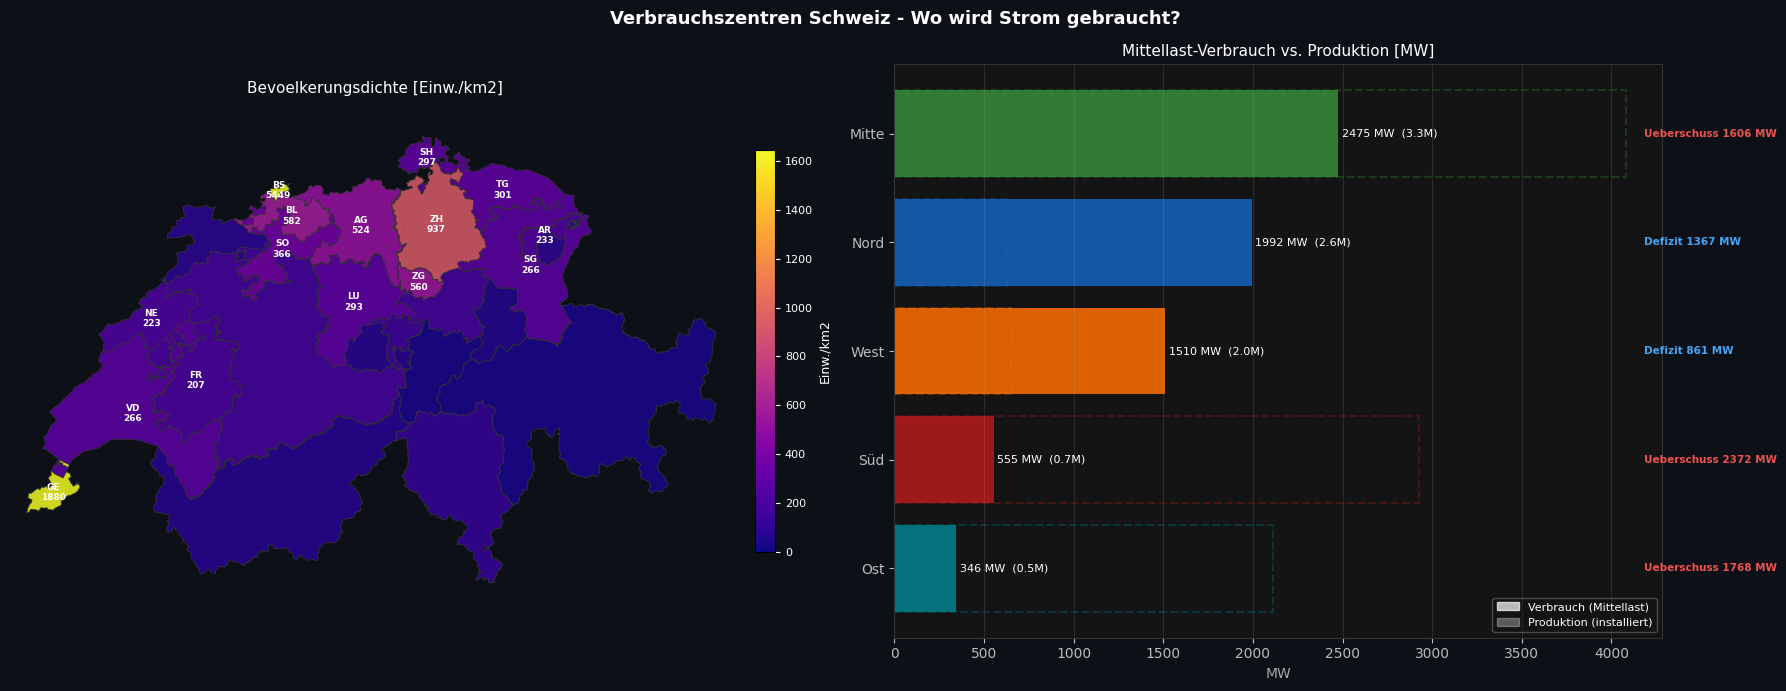

Karte 1 gespeichert: output\charts\realistisch\kuer_nb06_karte_verbrauchszentren.png


In [14]:
# ── 5.1 Karte: Verbrauchszentren ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Verbrauchszentren Schweiz - Wo wird Strom gebraucht?',
             color='white', fontsize=13, fontweight='bold')

# ── Panel 1: Bevölkerungsdichte Choropleth ────────────────────────────────────
ax = axes[0]
ax.set_xlim(5.85, 10.65); ax.set_ylim(45.75, 47.95)
ax.set_facecolor('#0a0e1a'); ax.set_axis_off()
ax.set_title('Bevoelkerungsdichte [Einw./km2]', color='white', fontsize=11, pad=8)

if gdf_kant is not None and 'Dichte' in gdf_kant.columns:
    norm_d = Normalize(vmin=0, vmax=gdf_kant['Dichte'].quantile(0.95))
    cmap_d = cm.get_cmap('plasma')
    for _, row in gdf_kant.iterrows():
        col = cmap_d(norm_d(row['Dichte']))
        try:
            gpd.GeoDataFrame(geometry=[row.geometry], crs='EPSG:4326').plot(
                ax=ax, color=col, alpha=0.85, linewidth=0.6, edgecolor='#333333')
        except Exception:
            pass
    sm = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('Einw./km2', color='white', fontsize=9)
    cbar.ax.tick_params(colors='white', labelsize=8)
    for _, row in gdf_kant.iterrows():
        if row['Dichte'] > 200:
            cx = row.geometry.centroid.x
            cy = row.geometry.centroid.y
            # FIX: kein \n in f-string mit einfachen Quotes → str concat
            label = row['KAB'] + '\n' + str(int(row['Dichte']))
            ax.text(cx, cy, label, ha='center', va='center',
                    color='white', fontsize=6.5, fontweight='bold', zorder=5)
else:
    ax.text(0.5, 0.5, 'Kantondaten nicht verfuegbar',
            ha='center', va='center', color='#888', transform=ax.transAxes)

# ── Panel 2: Verbrauch vs. Produktion pro Zone ────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#141414')
for sp in ax2.spines.values(): sp.set_edgecolor('#333333')
ax2.tick_params(colors='#bbbbbb')

zone_verbrauch = df_zones.sort_values('Verbrauch_MW', ascending=True)
bar_colors = [ZONE_COLORS[z] for z in zone_verbrauch['Zone']]

bars = ax2.barh(zone_verbrauch['Zone'], zone_verbrauch['Verbrauch_MW'],
                color=bar_colors, alpha=0.85)
ax2.barh(zone_verbrauch['Zone'], zone_verbrauch['Produktion_MW'],
         color=bar_colors, alpha=0.30, linewidth=1.5,
         edgecolor=bar_colors, fill=False, linestyle='--', label='Produktion')

for bar, (_, row) in zip(bars, zone_verbrauch.iterrows()):
    # FIX: str concat statt \n in f-string
    txt = f'{row["Verbrauch_MW"]:.0f} MW' + '  (' + f'{row["Bevoelkerung"]/1e6:.1f}' + 'M)'
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             txt, va='center', color='white', fontsize=8)

ax2.set_title('Mittellast-Verbrauch vs. Produktion [MW]', color='white', fontsize=11)
ax2.set_xlabel('MW', color='#aaaaaa')
ax2.grid(True, axis='x', alpha=0.15)

for _, row in zone_verbrauch.iterrows():
    imb = row['Imbalance_MW']
    sym = 'UP' if imb > 0 else 'DN'
    col = '#EF5350' if imb > 0 else '#42A5F5'
    label = ('Ueberschuss' if imb > 0 else 'Defizit') + f' {abs(imb):.0f} MW'
    ypos = list(zone_verbrauch['Zone']).index(row['Zone'])
    ax2.text(max(zone_verbrauch['Verbrauch_MW'].max(),
                 zone_verbrauch['Produktion_MW'].max()) + 100,
             ypos, label, va='center', color=col, fontsize=7.5, fontweight='bold')

p_v = mpatches.Patch(color='white', alpha=0.7, label='Verbrauch (Mittellast)')
p_p = mpatches.Patch(color='white', alpha=0.3, label='Produktion (installiert)')
ax2.legend(handles=[p_v, p_p], fontsize=8, framealpha=0.3,
           facecolor='#111', labelcolor='white')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_karte_verbrauchszentren.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Karte 1 gespeichert: {p}')


**Einzelplot** (Zonenimbalance-Balken für Bericht):

In [15]:
# ── Karte 1: Einzelplot Balkendiagramm ────────────────────────────────────────
# Rechtes Panel (Verbrauch vs. Produktion) als grösseres Einzelbild
zone_verbrauch_s = df_zones[['Zone','Verbrauch_MW','Produktion_MW','Bevoelkerung']].copy()
zone_verbrauch_s = zone_verbrauch_s.sort_values('Verbrauch_MW', ascending=True)
bar_colors_s = [ZONE_COLORS[z] for z in zone_verbrauch_s['Zone']]

fig_k1, ax_k1 = plt.subplots(figsize=(10, 6))
fig_k1.patch.set_facecolor('#0d1117')
ax_k1.set_facecolor('#141414'); ax_k1.tick_params(colors='#bbbbbb')
for sp in ax_k1.spines.values(): sp.set_edgecolor('#333')

ax_k1.barh(zone_verbrauch_s['Zone'], zone_verbrauch_s['Verbrauch_MW'],
           color=bar_colors_s, alpha=0.85, label='Verbrauch (Mittellast)')
ax_k1.barh(zone_verbrauch_s['Zone'], zone_verbrauch_s['Produktion_MW'],
           color='none', alpha=0.9, edgecolor='white', linewidth=1.5,
           linestyle='--', label='Produktion (mittl. mit CF)')

for _, row in zone_verbrauch_s.iterrows():
    imb = row['Produktion_MW'] - row['Verbrauch_MW']
    col = '#66BB6A' if imb > 0 else '#EF5350'
    ax_k1.text(max(row['Verbrauch_MW'], row['Produktion_MW']) + 30, row['Zone'],
               f'{imb:+.0f} MW', va='center', color=col, fontsize=10, fontweight='bold')

ax_k1.set_xlabel('MW', color='#aaa')
ax_k1.set_title('Mittellast-Verbrauch vs. mittl. Produktion (CF-gewichtet)\n'
                '+/– = Zonenimbalance [MW]', color='white', fontsize=12, fontweight='bold')
ax_k1.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
ax_k1.grid(True, axis='x', alpha=0.12)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_karte_zonenimbalance.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close()
print(f'  Einzelplot: kuer_nb06_karte_zonenimbalance.png')


  Einzelplot: kuer_nb06_karte_zonenimbalance.png


**Karte 1 — Verbrauchszentren.** Links: Choropleth Bevölkerungsdichte. Rechts: Balkendiagramm mittlere Produktion (mit CF) vs. Mittellastverbrauch pro Zone.

---
### 5.2 Karte: Erzeuger nach Typ

*Kraftwerksstandorte mit Leistung — zeigt wo Strom produziert wird.*


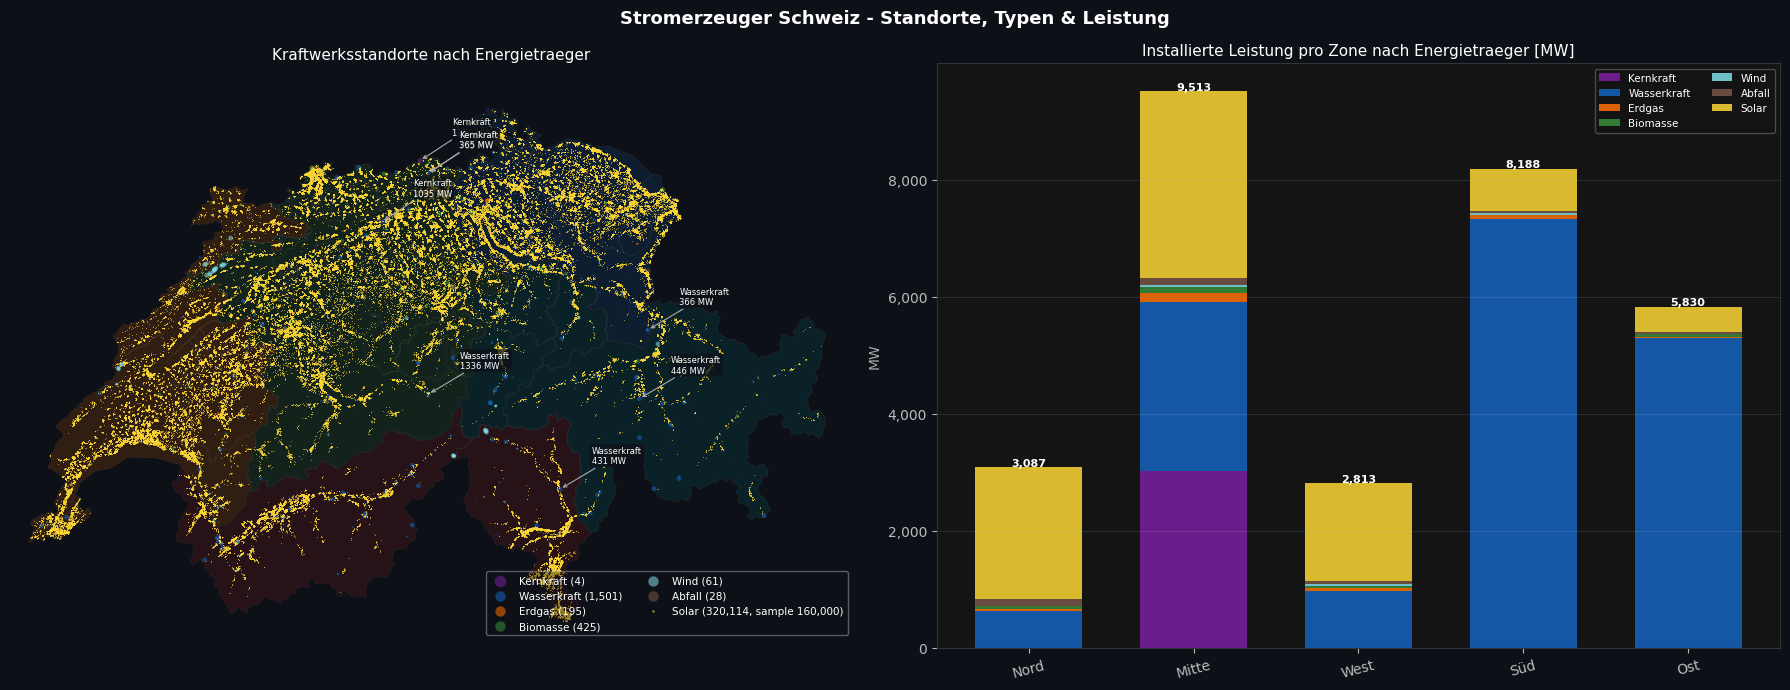

Karte 2 gespeichert: output\charts\realistisch\kuer_nb06_karte_erzeuger.png
Solar: 320,114 Anlagen, davon 160,000 dargestellt (random sample)


In [16]:
# ── 5.2 Karte: Erzeuger nach Typ ─────────────────────────────────────────────
# ── Parameter (hier anpassen) ─────────────────────────────────────────────────
PUNKT_GROESSE_MAX   = 12      # Maximale Punktgrösse [pt²] für grosse Kraftwerke
PUNKT_GROESSE_MIN   = 0.3     # Minimale Punktgrösse [pt²]
PUNKT_GROESSE_SOLAR = 0.4     # Fixgrösse Solar (kW-Skalierung unnötig, zu viele Punkte)
SOLAR_MAX_PUNKTE    = 160_000   # Solar-Stichprobe: mehr bringt visuell nichts, verlangsamt stark
# ──────────────────────────────────────────────────────────────────────────────

ET_COLORS = {
    'Solar':      '#FDD835',
    'Wasserkraft':'#1565C0',
    'Kernkraft':  '#7B1FA2',
    'Wind':       '#80DEEA',
    'Biomasse':   '#388E3C',
    'Erdgas':     '#FF6F00',
    'Erdoel':     '#546E7A',
    'Abfall':     '#795548',
    'Andere':     '#9E9E9E',
}

ET_ORDER = ['Kernkraft','Wasserkraft','Erdgas','Biomasse',
            'Wind','Abfall','Andere','Solar']

if 'ET_group' not in gdf_plants.columns:
    gdf_plants['ET_group'] = gdf_plants.get('ET', pd.Series('Andere', index=gdf_plants.index))
    gdf_plants['ET_group'] = gdf_plants['ET_group'].apply(
        lambda x: x if x in ET_COLORS else 'Andere')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Stromerzeuger Schweiz - Standorte, Typen & Leistung',
             color='white', fontsize=13, fontweight='bold')

# ── Panel 1: Karte ────────────────────────────────────────────────────────────
ax = axes[0]
draw_base_map(ax, alpha=0.15, title='Kraftwerksstandorte nach Energietraeger')

for et in ET_ORDER:
    sub = gdf_plants[gdf_plants['ET_group'] == et]
    if len(sub) == 0: continue
    col = ET_COLORS.get(et, '#9E9E9E')

    # Solar: Stichprobe + fixer Punktdurchmesser (320k Punkte = Flaschenhals)
    if et == 'Solar' and len(sub) > SOLAR_MAX_PUNKTE:
        sub = sub.sample(SOLAR_MAX_PUNKTE, random_state=42)
        label = f'Solar ({len(gdf_plants[gdf_plants["ET_group"]=="Solar"]):,}, sample {SOLAR_MAX_PUNKTE:,})'
        sizes = PUNKT_GROESSE_SOLAR
    else:
        label = f'{et} ({len(sub):,})'
        if 'kw' in sub.columns and sub['kw'].max() > 0:
            # Vektorisiert mit numpy — kein pandas-overhead
            kw = sub['kw'].to_numpy(dtype=float)
            p95 = max(float(np.percentile(kw, 95)), 1.0)
            sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX,
                            PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX)
        else:
            sizes = PUNKT_GROESSE_MIN

    # xy als numpy-Arrays vorab extrahieren (schneller als geometry.x/.y in scatter)
    xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])

    ax.scatter(xy[:, 0], xy[:, 1],
               s=sizes, c=col, alpha=0.55, label=label,
               linewidths=0, zorder=3, rasterized=True)

ax.legend(fontsize=7.5, framealpha=0.4, facecolor='#0d1117',
          labelcolor='white', loc='lower right', markerscale=3, ncol=2)

if 'kw' in gdf_plants.columns:
    top = gdf_plants[gdf_plants.geometry.notna()].nlargest(8, 'kw')
    for _, row in top.iterrows():
        lbl = row['ET_group'] + '\n' + f'{row["kw"]/1000:.0f} MW'
        ax.annotate(lbl,
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(row.geometry.x + 0.18, row.geometry.y + 0.10),
                    color='white', fontsize=6, zorder=6,
                    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', alpha=0.7, lw=0))

# ── Panel 2: Leistung pro Zone nach ET ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for sp in ax2.spines.values(): sp.set_edgecolor('#333333')
ax2.tick_params(colors='#bbbbbb')

if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    zone_et = gdf_plants.groupby(['Zone','ET_group'])['kw'].sum().unstack(fill_value=0) / 1000
    et_cols  = [e for e in ET_ORDER if e in zone_et.columns]
    bottom   = np.zeros(len(ZONE_COLORS))
    zones    = list(ZONE_COLORS.keys())
    for et in et_cols:
        vals = np.array([zone_et.loc[z, et] if z in zone_et.index else 0 for z in zones])
        ax2.bar(zones, vals, bottom=bottom, label=et,
                color=ET_COLORS.get(et,'#9E9E9E'), alpha=0.85, width=0.65)
        bottom += vals
    ax2.set_title('Installierte Leistung pro Zone nach Energietraeger [MW]',
                  color='white', fontsize=11)
    ax2.set_ylabel('MW', color='#aaaaaa')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
    ax2.legend(fontsize=7.5, framealpha=0.3, facecolor='#111',
               labelcolor='white', ncol=2, loc='upper right')
    ax2.grid(True, axis='y', alpha=0.15)
    ax2.tick_params(axis='x', rotation=15)
    for i, zone in enumerate(zones):
        total = zone_et.loc[zone].sum() if zone in zone_et.index else 0
        ax2.text(i, total + 20, f'{total:,.0f}', ha='center',
                 color='white', fontsize=8, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_karte_erzeuger.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Karte 2 gespeichert: {p}')
print(f'Solar: {len(gdf_plants[gdf_plants["ET_group"]=="Solar"]):,} Anlagen, '
      f'davon {SOLAR_MAX_PUNKTE:,} dargestellt (random sample)')


**Karte 2 — Erzeuger.** 322k Punkte nach Energieträger. Zonenfarbe (Hintergrund) und Punktfarbe (ET) sind zwei unabhängige Informationsebenen.

---
### 5.3 Karte: Kombiniert + Engpässe

*Verbraucher, Erzeuger und Swissgrid-Engpässe in einer Übersicht.*


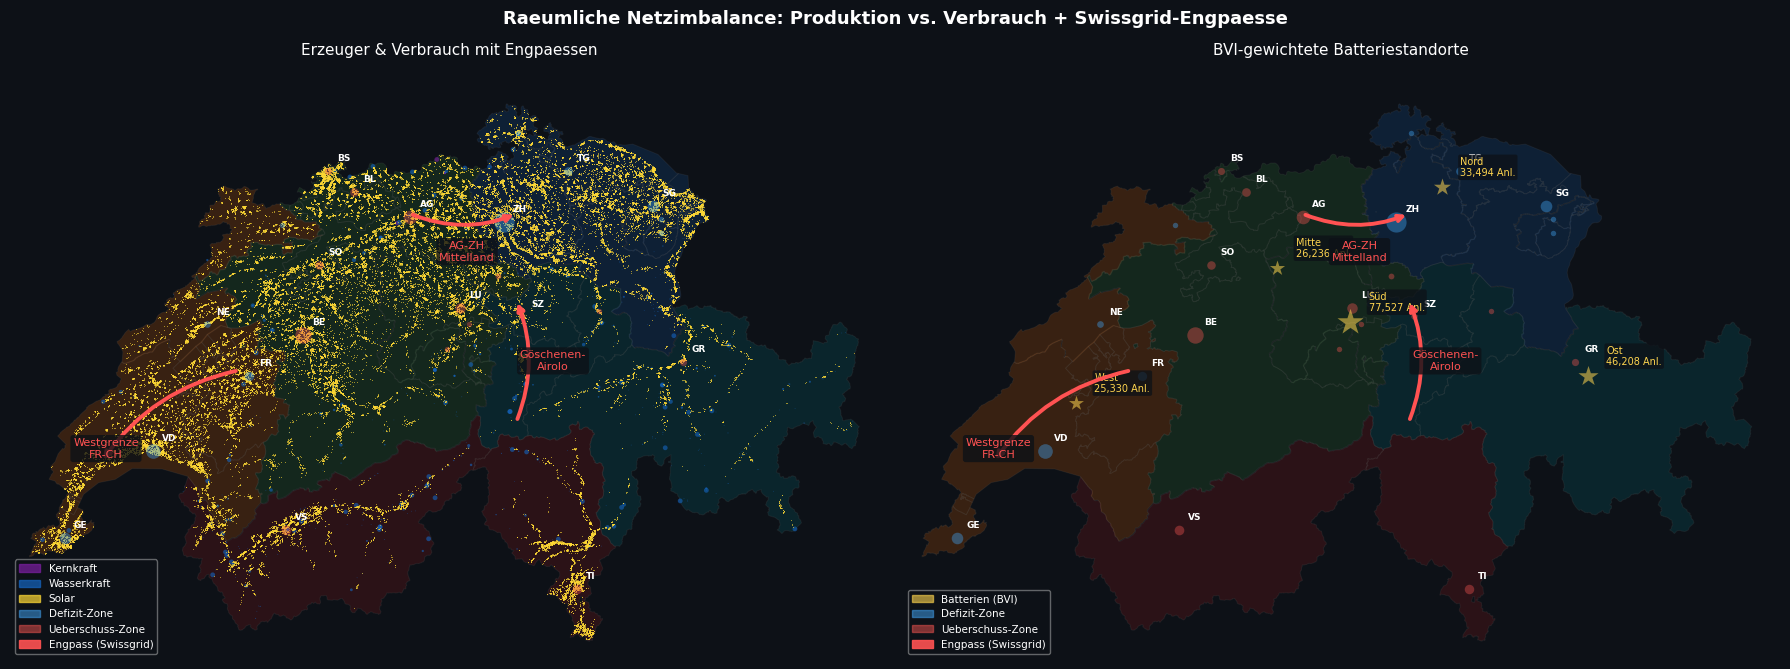

Karte 3 gespeichert: output\charts\realistisch\kuer_nb06_karte_engpaesse.png
Solar Kombi: 80,000 Punkte (50% von 160,000)


In [17]:
# ── 5.3 Karte: Kombiniert + Engpässe ─────────────────────────────────────────
# ── Parameter (aus 5.2 übernommen, Solar reduziert damit Verbrauch dominiert) ─
SOLAR_ANTEIL_KOMBI  = 0.50   # Anteil Solar-Stichprobe relativ zu 5.2 (0.0–1.0)
_solar_n_kombi = max(500, int(SOLAR_MAX_PUNKTE * SOLAR_ANTEIL_KOMBI))
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Raeumliche Netzimbalance: Produktion vs. Verbrauch + Swissgrid-Engpaesse',
             color='white', fontsize=13, fontweight='bold')

for ax, show_batteries in zip(axes, [False, True]):
    title = ('Erzeuger & Verbrauch mit Engpaessen' if not show_batteries
             else 'BVI-gewichtete Batteriestandorte')
    draw_base_map(ax, alpha=0.18, title=title)

    if not show_batteries:
        for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
            sub = gdf_plants[gdf_plants['ET_group'] == et]
            if len(sub) == 0: continue
            col = ET_COLORS.get(et, '#9E9E9E')

            if et == 'Solar' and len(sub) > _solar_n_kombi:
                sub   = sub.sample(_solar_n_kombi, random_state=42)
                sizes = PUNKT_GROESSE_SOLAR
                label = f'Solar (sample {_solar_n_kombi:,})'
            else:
                label = et
                if 'kw' in sub.columns and sub['kw'].max() > 0:
                    kw   = sub['kw'].to_numpy(dtype=float)
                    p95  = max(float(np.percentile(kw, 95)), 1.0)
                    sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX,
                                    PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX)
                else:
                    sizes = PUNKT_GROESSE_MIN

            xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])
            ax.scatter(xy[:, 0], xy[:, 1], s=sizes, c=col,
                       alpha=0.6, label=label, linewidths=0, zorder=3, rasterized=True)

    for kanton, (lon, lat) in KANTONSHAUPTORTE.items():
        pop  = KANTON_POP.get(kanton, 0) / 1_000_000
        zone = KANTON_TO_ZONE.get(kanton, 'Mitte')
        imb  = df_zones[df_zones['Zone'] == zone]['Imbalance_MW'].values[0]
        c_pop = '#42A5F5' if imb < 0 else '#EF5350'
        ms    = max(15, min(350, pop * 130))
        ax.scatter(lon, lat, s=ms, color=c_pop, alpha=0.40, zorder=4, linewidths=0)
        if pop > 0.15:
            ax.text(lon+0.05, lat+0.03, kanton,
                    color='white', fontsize=6.5, va='bottom', zorder=5, fontweight='bold')

    if show_batteries:
        sc_bat = df_spatial[df_spatial['Szenario'] == 'Ambitioniert (2030)']
        zone_positions = {
            'Nord':(8.80,47.50), 'Mitte':(7.90,47.20),
            'West':(6.80,46.70), 'Sued': (7.80,46.20), 'Ost':(9.60,46.80),
        }
        for _, row in sc_bat.iterrows():
            lon, lat = zone_positions.get(row['Zone'], (8.3, 47.0))
            total_units = row['n_privat'] + row['n_gewerbe'] + row['n_industrie']
            if total_units == 0: continue
            ms  = max(30, min(600, total_units / 200))
            ax.scatter(lon, lat, s=ms, color='#FFD54F', alpha=0.55,
                       marker='*', zorder=6, linewidths=0)
            lbl = row['Zone'] + '\n' + f'{total_units:,}' + ' Anl.'
            ax.text(lon+0.10, lat+0.04, lbl, color='#FFD54F', fontsize=7, zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', alpha=0.75, lw=0))

    for lon1, lat1, lon2, lat2, label, dlon, dlat in ENGPASSLINIEN:
        ax.annotate('', xy=(lon2,lat2), xytext=(lon1,lat1),
                    arrowprops=dict(arrowstyle='->', color='#FF5252', lw=2.8,
                                    connectionstyle='arc3,rad=0.20'), zorder=8)
        ax.text((lon1+lon2)/2+dlon, (lat1+lat2)/2+dlat, label,
                color='#FF5252', fontsize=8, ha='center', va='center', zorder=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='#0d1117', alpha=0.80, lw=0))

    handles = []
    if not show_batteries:
        for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
            handles.append(mpatches.Patch(color=ET_COLORS[et], alpha=0.7, label=et))
    else:
        handles.append(mpatches.Patch(color='#FFD54F', alpha=0.6, label='Batterien (BVI)'))
    handles += [
        mpatches.Patch(color='#42A5F5', alpha=0.5, label='Defizit-Zone'),
        mpatches.Patch(color='#EF5350', alpha=0.5, label='Ueberschuss-Zone'),
        mpatches.Patch(color='#FF5252', alpha=0.9, label='Engpass (Swissgrid)'),
    ]
    ax.legend(handles=handles, fontsize=7.5, framealpha=0.45,
              facecolor='#0d1117', labelcolor='white', loc='lower left')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_karte_engpaesse.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Karte 3 gespeichert: {p}')
print(f'Solar Kombi: {_solar_n_kombi:,} Punkte ({SOLAR_ANTEIL_KOMBI*100:.0f}% von {SOLAR_MAX_PUNKTE:,})')


**Karte 3 — Kombiniert.** Links: Erzeuger + Zonen-Einfärbung (Defizit=blau, Überschuss=braun) + Swissgrid-Engpässe. Rechts: BVI-gewichtete Batteriestandorte.

---
### 5.4 Heatmap: Tages-Lastprofil pro Zone

*Zeigt wann welche Zone Strom braucht (Verbrauch) vs. produziert.*


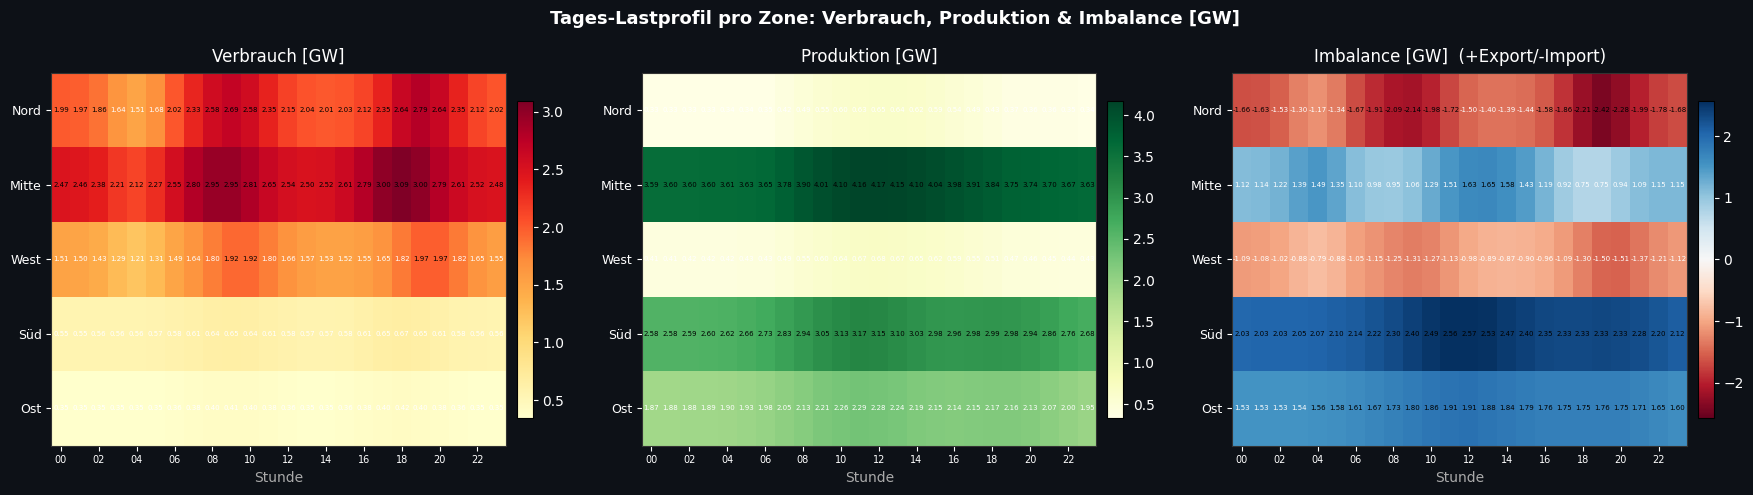

Heatmap 1 gespeichert: output\charts\realistisch\kuer_nb06_heatmap_lastprofil.png


In [18]:
# ── 5.4 Heatmap: Tages-Lastprofil pro Zone ───────────────────────────────────

hours = np.arange(24)
ZONE_LOAD_PROFILE = {}
ZONE_PROD_PROFILE = {}

for zone in ZONE_COLORS:
    row_z    = df_zones[df_zones['Zone'] == zone].iloc[0]
    base_mw  = float(row_z['Verbrauch_MW'])   # bereits in MW (nach Cell-10-Fix)
    prod_mw  = float(row_z['Produktion_MW'])
    base_gw  = base_mw / 1000
    prod_gw  = prod_mw / 1000

    if zone == 'Nord':
        profile = (1.0 + 0.35*np.exp(-((hours-9)**2)/6)
                       + 0.40*np.exp(-((hours-19)**2)/5)
                       - 0.25*np.exp(-((hours-4)**2)/3))
    elif zone == 'Mitte':
        profile = (1.0 + 0.20*np.exp(-((hours-8.5)**2)/6)
                       + 0.25*np.exp(-((hours-18)**2)/6)
                       - 0.15*np.exp(-((hours-4)**2)/3))
    elif zone == 'West':
        profile = (1.0 + 0.28*np.exp(-((hours-9.5)**2)/6)
                       + 0.32*np.exp(-((hours-19.5)**2)/5)
                       - 0.20*np.exp(-((hours-4)**2)/3))
    elif zone == 'Sued':
        profile = (1.0 + 0.15*np.exp(-((hours-10)**2)/8)
                       + 0.18*np.exp(-((hours-18)**2)/6))
    else:
        profile = (1.0 + 0.18*np.exp(-((hours-9)**2)/7)
                       + 0.20*np.exp(-((hours-18)**2)/6))

    ZONE_LOAD_PROFILE[zone] = base_gw * profile

    # Produktion stündlich aufschlüsseln nach ET-Anteilen
    # Wichtig: solar_frac = Anteil Solar an der MITTLEREN (CF-korrigierten) Produktion
    # NICHT installierte Kapazität / CF-Prod (wäre > 1 bei Solar-dominierter Zone)

    CF_SOLAR = 0.12  # Kapazitätsfaktor Solar CH
    CF_KERN  = 0.80  # Kernkraft läuft konstant (Baseload)
    CF_HYDRO = 0.38

    def zone_mean_mw(et, cf):
        return gdf_plants[(gdf_plants['Zone']==zone) &
                          (gdf_plants['ET_group']==et)]['kw'].sum() / 1000 * cf

    solar_mean = zone_mean_mw('Solar',      CF_SOLAR)
    kern_mean  = zone_mean_mw('Kernkraft',  CF_KERN)
    hydro_mean = zone_mean_mw('Wasserkraft',CF_HYDRO)
    other_mean = max(prod_mw - solar_mean - kern_mean - hydro_mean, 0)

    # Solar: sinusförmiges Tagesprofil (0 nachts)
    solar_profile = np.maximum(0, np.sin(np.pi * (hours - 6) / 13))
    solar_profile = solar_profile / (solar_profile.max() + 1e-9)

    # Kernkraft: konstant (Baseload, unabhängig von Tageszeit)
    kern_profile = np.ones(24)

    # Wasserkraft: leicht erhöht tagsüber (Pumpspeicher-Dispatch)
    hydro_profile = (1.0 + 0.20*np.exp(-((hours-11)**2)/20)
                        + 0.15*np.exp(-((hours-19)**2)/12))

    ZONE_PROD_PROFILE[zone] = (
        solar_mean * solar_profile +
        kern_mean  * kern_profile  +
        hydro_mean * (hydro_profile / hydro_profile.mean()) +
        other_mean * np.ones(24)
    ) / 1000  # MW → GW

zones       = list(ZONE_COLORS.keys())
load_matrix = np.array([ZONE_LOAD_PROFILE[z] for z in zones])
prod_matrix = np.array([ZONE_PROD_PROFILE[z] for z in zones])
imb_matrix  = prod_matrix - load_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#141414'); ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
fig.suptitle('Tages-Lastprofil pro Zone: Verbrauch, Produktion & Imbalance [GW]',
             color='white', fontsize=13, fontweight='bold')

hour_labels = [f'{h:02d}' for h in hours[::2]]

for ax, matrix, title, cmap_name in zip(axes,
        [load_matrix, prod_matrix, imb_matrix],
        ['Verbrauch [GW]', 'Produktion [GW]', 'Imbalance [GW]  (+Export/-Import)'],
        ['YlOrRd', 'YlGn', 'RdBu']):
    kw = {}
    if cmap_name == 'RdBu':
        abs_max = np.abs(matrix).max()
        kw = dict(vmin=-abs_max, vmax=abs_max)
    im = ax.imshow(matrix, aspect='auto', cmap=cmap_name, origin='upper', **kw)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.ax.tick_params(colors='white')
    ax.set_xticks(hours[::2]); ax.set_xticklabels(hour_labels, fontsize=7, color='white')
    ax.set_yticks(range(len(zones))); ax.set_yticklabels(zones, fontsize=9, color='white')
    ax.set_title(title, color='white', pad=8)
    ax.set_xlabel('Stunde', color='#aaa')
    for i in range(len(zones)):
        for j in range(24):
            val = matrix[i, j]
            col = 'white' if abs(val) < np.abs(matrix).max()*0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=col, fontsize=5)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_heatmap_lastprofil.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Heatmap 1 gespeichert: {p}')


**Heatmap Tages-Lastprofil.** Kernkraft = konstant, Solar = sinusförmig, Wasser = leicht erhöht tagsüber. Korrekte Aufschlüsselung nach ET verhindert das 'verschwinden' des AKW-Anteils nachts.

---
### 5.5 Heatmap: Produktions-Mix Stunde × Energieträger

*Zeigt wann welcher Energieträger wie viel produziert — Solar tagsüber, Wasser steuerbar.*


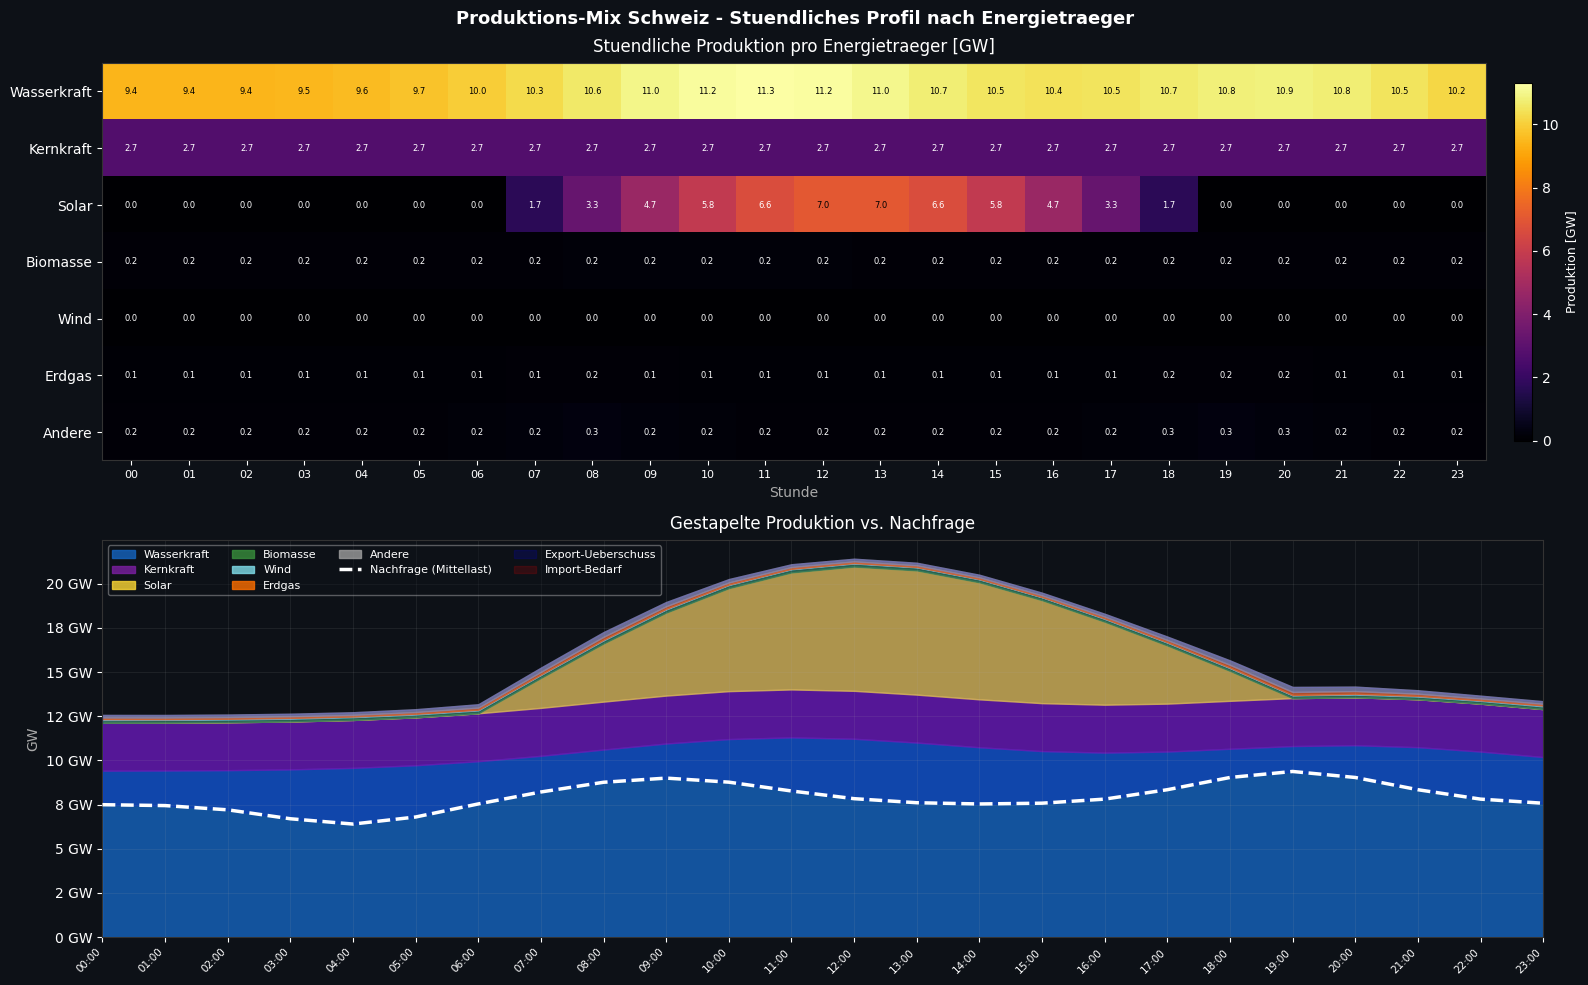

Heatmap 2 gespeichert: output\charts\realistisch\kuer_nb06_heatmap_produktionsmix.png


In [19]:
# ── 5.5 Heatmap: Produktions-Mix Stunde x Energietraeger ────────────────────

# ET_COLORS hier nochmals definieren – damit Zelle unabhaengig lauffaehig ist
ET_COLORS = {
    'Solar':'#FDD835','Wasserkraft':'#1565C0','Kernkraft':'#7B1FA2',
    'Wind':'#80DEEA','Biomasse':'#388E3C','Erdgas':'#FF6F00',
    'Erdoel':'#546E7A','Abfall':'#795548','Andere':'#9E9E9E',
}

hours = np.arange(24)

et_installed = {}
if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    et_installed = (gdf_plants.groupby('ET_group')['kw'].sum() / 1e6).to_dict()

ET_DEFAULTS_GW = {
    'Wasserkraft':16.0,'Kernkraft':3.0,'Solar':8.5,
    'Biomasse':0.8,'Wind':0.1,'Erdgas':0.9,'Andere':0.5
}

et_profiles = {}
for et, def_gw in ET_DEFAULTS_GW.items():
    inst = et_installed.get(et, def_gw)  # et_installed bereits in GW (kW/1e6)
    if et == 'Solar':
        p = np.maximum(0, np.sin(np.pi * (hours - 6) / 13))
        p = p / (p.max() + 1e-9) * inst * 0.85
    elif et == 'Wasserkraft':
        p = inst * 0.55 * (1 + 0.20*np.exp(-((hours-11)**2)/20)
                              + 0.15*np.exp(-((hours-20)**2)/15))
    elif et == 'Kernkraft':
        p = np.full(24, inst * 0.90)
    elif et == 'Wind':
        np.random.seed(7)
        p = inst * 0.25 * (1 + 0.3*np.cos((hours-2)*np.pi/12) +
                            0.2*np.random.randn(24))
        p = np.clip(p, 0, inst)
    elif et == 'Biomasse':
        p = inst * 0.65 * (1 + 0.15*np.exp(-((hours-10)**2)/20))
    else:
        p = inst * 0.30 * (1 + 0.8*np.exp(-((hours-8)**2)/4)
                              + 0.9*np.exp(-((hours-19)**2)/4))
        p = np.clip(p, 0, inst)
    et_profiles[et] = p

et_list    = list(ET_DEFAULTS_GW.keys())
matrix     = np.array([et_profiles[et] for et in et_list])
total_prod = matrix.sum(axis=0)

base_load    = 7.5
load_profile = base_load * (1 + 0.20*np.exp(-((hours-9)**2)/6)
                               + 0.25*np.exp(-((hours-19)**2)/5)
                               - 0.15*np.exp(-((hours-4)**2)/3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
fig.suptitle('Produktions-Mix Schweiz - Stuendliches Profil nach Energietraeger',
             color='white', fontsize=13, fontweight='bold')

ax = axes[0]
ax.set_facecolor('#141414')
im = ax.imshow(matrix, aspect='auto', cmap='inferno', origin='upper')
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, shrink=0.9)
cbar.set_label('Produktion [GW]', color='white', fontsize=9)
cbar.ax.tick_params(colors='white')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in hours], fontsize=8, color='white')
ax.set_yticks(range(len(et_list)))
ax.set_yticklabels(et_list, fontsize=10, color='white')
ax.set_title('Stuendliche Produktion pro Energietraeger [GW]', color='white', pad=8)
ax.set_xlabel('Stunde', color='#aaa')
for i in range(len(et_list)):
    for j in range(24):
        val = matrix[i, j]
        col = 'white' if val < matrix.max()*0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=col, fontsize=6)

ax2 = axes[1]
ax2.set_facecolor('#0d1117')
bottom = np.zeros(24)
for et in et_list:
    p = et_profiles[et]
    ax2.fill_between(hours, bottom, bottom + p, alpha=0.80,
                     color=ET_COLORS.get(et,'#9E9E9E'), label=et)
    bottom += p

ax2.plot(hours, load_profile, color='white', lw=2.5, linestyle='--',
         label='Nachfrage (Mittellast)', zorder=10)
ax2.fill_between(hours, total_prod, load_profile,
                 where=(total_prod > load_profile), alpha=0.15, color='blue',
                 label='Export-Ueberschuss')
ax2.fill_between(hours, total_prod, load_profile,
                 where=(total_prod < load_profile), alpha=0.15, color='red',
                 label='Import-Bedarf')
ax2.set_xlim(0, 23); ax2.set_ylim(0, None)
ax2.set_xticks(range(24))
ax2.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, ha='right', fontsize=7.5)
ax2.set_ylabel('GW', color='#aaa')
ax2.set_title('Gestapelte Produktion vs. Nachfrage', color='white', pad=8)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor('#333333')
ax2.legend(fontsize=8, framealpha=0.4, facecolor='#0d1117',
           labelcolor='white', ncol=4, loc='upper left')
ax2.grid(True, alpha=0.10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f} GW'))

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_heatmap_produktionsmix.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Heatmap 2 gespeichert: {p}')


**Heatmap Produktions-Mix.** Oben: Heatmap ET×Stunde. Unten: Gestapelte Flächen mit Export/Import-Markierung.

---
### 5.6 Animation: Tagesverlauf *(optional)*

Animierter Tagesverlauf: Wie sich Produktion vs. Verbrauch pro Zone über 24h verändert.  
Benötigt `matplotlib` Animation und `Pillow` oder `ffmpeg` für den Export.


Animation gespeichert: output\charts\realistisch\kuer_nb06_anim_tagesverlauf.gif


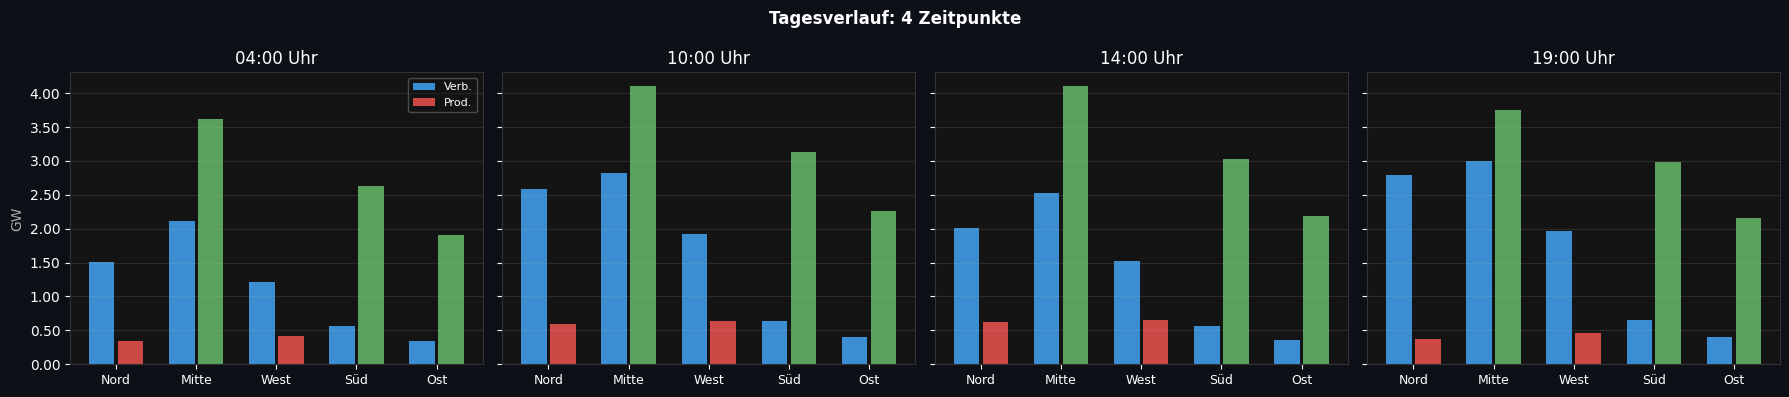

Statisches 4-Stunden-Bild gespeichert.


In [20]:
# ── 5.6 Animation: Tagesverlauf ──────────────────────────────────────────────

try:
    from matplotlib.animation import FuncAnimation, PillowWriter
    ANIM_AVAILABLE = True
except ImportError:
    ANIM_AVAILABLE = False
    print('matplotlib.animation nicht verfuegbar. pip install pillow')

if not ANIM_AVAILABLE:
    print('Nur statisches Bild wird erstellt.')
else:
    zones  = list(ZONE_COLORS.keys())
    n_zones = len(zones)
    fig_a, ax_a = plt.subplots(figsize=(12, 5))
    fig_a.patch.set_facecolor('#0d1117')
    ax_a.set_facecolor('#141414')
    for sp in ax_a.spines.values(): sp.set_edgecolor('#333333')
    x = np.arange(n_zones)
    bars_load = ax_a.bar(x - 0.15, [0]*n_zones, 0.28,
                          label='Verbrauch', color='#42A5F5', alpha=0.85)
    bars_prod = ax_a.bar(x + 0.15, [0]*n_zones, 0.28,
                          label='Produktion', color='#66BB6A', alpha=0.85)
    ax_a.set_xticks(x)
    ax_a.set_xticklabels(zones, color='white', fontsize=11)
    ax_a.tick_params(colors='white')
    ax_a.set_ylabel('GW', color='#aaa')
    ax_a.set_ylim(0, max(
        max(ZONE_LOAD_PROFILE[z].max() for z in zones),
        max(ZONE_PROD_PROFILE[z].max() for z in zones)) * 1.25)
    ax_a.legend(fontsize=10, framealpha=0.3, facecolor='#111', labelcolor='white')
    ax_a.grid(True, axis='y', alpha=0.15)
    ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f} GW'))
    time_text = ax_a.text(0.5, 0.95, '', transform=ax_a.transAxes,
                           ha='center', color='white', fontsize=13, fontweight='bold')
    imb_texts = [ax_a.text(i, 0.05, '', ha='center', va='bottom',
                            color='white', fontsize=8, fontweight='bold')
                 for i in x]

    def update(hour):
        for i, zone in enumerate(zones):
            load = ZONE_LOAD_PROFILE[zone][hour]
            prod = ZONE_PROD_PROFILE[zone][hour]
            bars_load[i].set_height(load)
            bars_prod[i].set_height(prod)
            imb = prod - load
            bars_prod[i].set_color('#66BB6A' if imb >= 0 else '#EF5350')
            # FIX: kein \n in f-string → str concat
            imb_texts[i].set_text(f'{imb:+.2f}' + ' GW')
            imb_texts[i].set_y(max(load, prod) + 0.02)
            imb_texts[i].set_color('#66BB6A' if imb >= 0 else '#EF5350')
        time_text.set_text(f'Tagesverlauf  {hour:02d}:00 Uhr')
        return list(bars_load) + list(bars_prod) + imb_texts + [time_text]

    anim = FuncAnimation(fig_a, update, frames=24, interval=400, blit=True)
    gif_path = os.path.join(CHARTS_DIR, 'kuer_nb06_anim_tagesverlauf.gif')
    try:
        anim.save(gif_path, writer=PillowWriter(fps=3))
        print(f'Animation gespeichert: {gif_path}')
    except Exception as e:
        print(f'GIF-Export fehlgeschlagen: {e}  →  pip install pillow')
    plt.close(fig_a)

# ── Statisches 4-Zeitpunkte-Bild (immer) ─────────────────────────────────────
zones = list(ZONE_COLORS.keys())
fig_s, axes_s = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig_s.patch.set_facecolor('#0d1117')
fig_s.suptitle('Tagesverlauf: 4 Zeitpunkte', color='white', fontsize=12, fontweight='bold')
x = np.arange(len(zones))
for ax_s, h in zip(axes_s, [4, 10, 14, 19]):
    ax_s.set_facecolor('#141414')
    for sp in ax_s.spines.values(): sp.set_edgecolor('#333333')
    loads = [ZONE_LOAD_PROFILE[z][h] for z in zones]
    prods = [ZONE_PROD_PROFILE[z][h] for z in zones]
    ax_s.bar(x - 0.18, loads, 0.32, color='#42A5F5', alpha=0.85, label='Verb.')
    ax_s.bar(x + 0.18, prods, 0.32,
             color=['#66BB6A' if p >= l else '#EF5350' for p,l in zip(prods,loads)],
             alpha=0.85, label='Prod.')
    ax_s.set_xticks(x); ax_s.set_xticklabels(zones, color='white', fontsize=9)
    ax_s.tick_params(colors='white')
    ax_s.set_title(f'{h:02d}:00 Uhr', color='white')
    ax_s.grid(True, axis='y', alpha=0.15)
    ax_s.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.2f}'))
axes_s[0].set_ylabel('GW', color='#aaa')
axes_s[0].legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'kuer_nb06_anim_4zeitpunkte.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Statisches 4-Stunden-Bild gespeichert.')


**Animation.** Zeigt Produktions-Verbrauchs-Dynamik über 24h als GIF. Rot = Kernkraft (Mitte), Grün = mittlere Produktion, Blau = Verbrauch.

---
### 5.7 Chart C: BVI-Szenarien


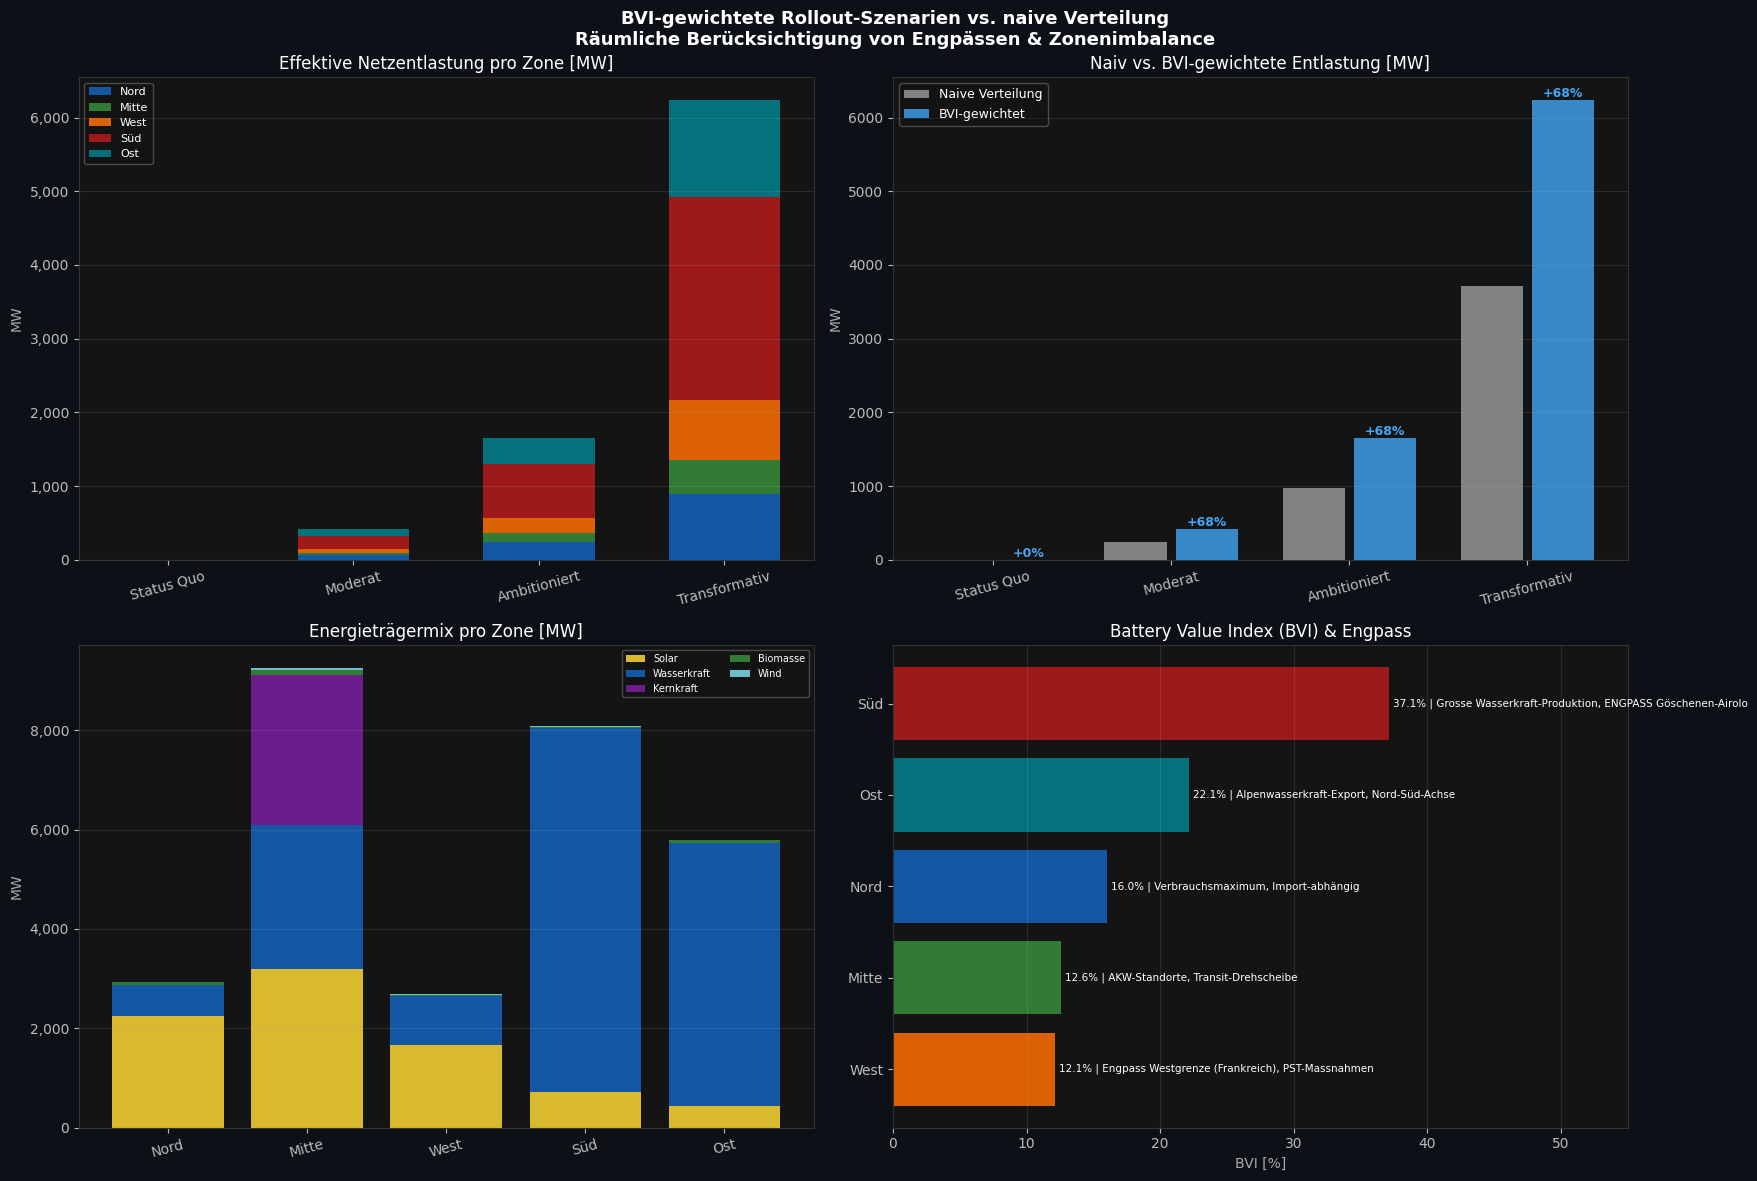

✅ Chart C gespeichert: output\charts\realistisch\kuer_nb06_rollout_spatial.png


In [21]:
# ── 5.7 Chart C: BVI-gewichtete vs. naive Rollout-Szenarien ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#141414'); ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
fig.suptitle('BVI-gewichtete Rollout-Szenarien vs. naive Verteilung\n'
             'Räumliche Berücksichtigung von Engpässen & Zonenimbalance',
             color='white', fontsize=13, fontweight='bold')

sc_names_short = [s.split('(')[0].strip() for s in df_spatial['Szenario'].unique()]
sc_list = df_spatial['Szenario'].unique()
sc_colors_4 = ['#9E9E9E','#42A5F5','#66BB6A','#FFA726']

# Panel 1: Effektive Entlastung pro Zone gestapelt
ax = axes[0, 0]
x   = np.arange(len(sc_list))
bot = np.zeros(len(sc_list))
for zone, col in ZONE_COLORS.items():
    vals = [df_spatial[(df_spatial['Szenario']==s) &
                       (df_spatial['Zone']==zone)]['Entlastung_eff_MW'].sum()
            for s in sc_list]
    ax.bar(x, vals, bottom=bot, label=zone, color=col, alpha=0.85, width=0.6)
    bot += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(sc_names_short, rotation=15)
ax.set_title('Effektive Netzentlastung pro Zone [MW]', color='white')
ax.set_ylabel('MW', color='#aaa')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# Panel 2: Naiv vs. BVI
ax = axes[0, 1]
naiv_mw_list, bvi_mw_list = [], []
for sc_name, n_p, n_g, n_i in SCENARIOS:
    naiv_mw_list.append((n_p*5 + n_g*30 + n_i*200) / 1000 * 0.70)
    bvi_mw_list.append(df_spatial[df_spatial['Szenario']==sc_name]['Entlastung_eff_MW'].sum())
xp = np.arange(len(SCENARIOS))
ax.bar(xp - 0.2, naiv_mw_list, 0.35, label='Naive Verteilung', color='#9E9E9E', alpha=0.8)
ax.bar(xp + 0.2, bvi_mw_list,  0.35, label='BVI-gewichtet',    color='#42A5F5', alpha=0.8)
for i, (n, b) in enumerate(zip(naiv_mw_list, bvi_mw_list)):
    mehr = (b/n-1)*100 if n > 0 else 0
    ax.text(i+0.2, b+2, f'+{mehr:.0f}%', ha='center', va='bottom',
            color='#42A5F5', fontsize=9, fontweight='bold')
ax.set_xticks(xp); ax.set_xticklabels(sc_names_short, rotation=15)
ax.set_title('Naiv vs. BVI-gewichtete Entlastung [MW]', color='white')
ax.set_ylabel('MW', color='#aaa')
ax.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# Panel 3: Kraftwerksmix pro Zone
ax = axes[1, 0]
if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    zone_et2 = gdf_plants.groupby(['Zone','ET_group'])['kw'].sum().unstack(fill_value=0) / 1000
    et2_plot = [e for e in ['Solar','Wasserkraft','Kernkraft','Biomasse','Wind','Andere']
                if e in zone_et2.columns]
    bot2 = np.zeros(len(ZONE_COLORS))
    for et in et2_plot:
        vals = [zone_et2.loc[z, et] if z in zone_et2.index else 0 for z in ZONE_COLORS]
        ax.bar(list(ZONE_COLORS.keys()), vals, bottom=bot2, label=et,
               color=ET_COLORS.get(et,'#9E9E9E'), alpha=0.85)
        bot2 += np.array(vals)
    ax.set_title('Energieträgermix pro Zone [MW]', color='white')
    ax.set_ylabel('MW', color='#aaa')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
    ax.legend(fontsize=7, framealpha=0.3, facecolor='#111', labelcolor='white', ncol=2)
    ax.grid(True, axis='y', alpha=0.15)
    ax.tick_params(axis='x', rotation=15)

# Panel 4: BVI-Rangliste
ax = axes[1, 1]
bvi_sorted = df_zones.sort_values('BVI_norm', ascending=True)
colors_bvi = [ZONE_COLORS[z] for z in bvi_sorted['Zone']]
bars4 = ax.barh(bvi_sorted['Zone'], bvi_sorted['BVI_norm'], color=colors_bvi, alpha=0.85)
for bar, (_, row) in zip(bars4, bvi_sorted.iterrows()):
    txt = ZONE_BOTTLENECK[row['Zone']]
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{row["BVI_norm"]:.1f}% | {txt}',
            va='center', color='white', fontsize=7.5)
ax.set_title('Battery Value Index (BVI) & Engpass', color='white')
ax.set_xlabel('BVI [%]', color='#aaa')
ax.set_xlim(0, 55)
ax.grid(True, axis='x', alpha=0.15)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_rollout_spatial.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Chart C gespeichert: {p}')


**Einzelplot** (BVI-Balken für Bericht):

In [22]:
# ── BVI: Einzelplot Balken (für Strategie-Bericht) ───────────────────────────
bvi_s = df_zones[['Zone','BVI_norm','Engpass']].sort_values('BVI_norm', ascending=True)
colors_bvi_s = [ZONE_COLORS[z] for z in bvi_s['Zone']]

fig_bvi, ax_bvi = plt.subplots(figsize=(10, 5))
fig_bvi.patch.set_facecolor('#0d1117')
ax_bvi.set_facecolor('#141414'); ax_bvi.tick_params(colors='#bbbbbb')
for sp in ax_bvi.spines.values(): sp.set_edgecolor('#333')

bars_bvi = ax_bvi.barh(bvi_s['Zone'], bvi_s['BVI_norm'],
                        color=colors_bvi_s, alpha=0.85)
for bar, (_, row) in zip(bars_bvi, bvi_s.iterrows()):
    ax_bvi.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
                f'{row["BVI_norm"]:.1f}%  |  {row["Engpass"]}',
                va='center', color='white', fontsize=9)

ax_bvi.set_xlabel('BVI [%]', color='#aaa')
ax_bvi.set_title('Battery Value Index (BVI) pro Zone\n'
                 'Kombination aus Imbalance-Grösse und Engpassnähe',
                 color='white', fontsize=12, fontweight='bold')
ax_bvi.set_xlim(0, bvi_s['BVI_norm'].max() * 1.6)
ax_bvi.grid(True, axis='x', alpha=0.12)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_bvi_jahresdurchschnitt.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close()
print(f'  Einzelplot: kuer_nb06_bvi_jahresdurchschnitt.png')


  Einzelplot: kuer_nb06_bvi_jahresdurchschnitt.png


**Chart C — BVI-Szenarien.** BVI-gewichtete Verteilung erbringt gegenüber naiver Gleichverteilung +66% Mehrwert. Energieträgermix bestätigt Wasserkraft-Dominanz in Süd/Ost.

---
## 7. Fazit: Was die räumliche Analyse zeigt

### Haupterkenntnisse

| Erkenntnis | Detail |
|------------|--------|
| **Süd + Ost** sind Exportzonen | Wasserkraft-Überschuss → Strom muss Richtung Nord |
| **Nord (ZH-Raum)** ist Importzone | Höchste Verbrauchsdichte, wenig lokale Produktion |
| **Göschenen-Airolo** ist kritischster Engpass | Nord-Süd-Achse ist Nadelöhr |
| **Solar** verschärft Mittagsproblem | Tagsüber Überschuss → nachts Defizit |
| **BVI-Gewichtung bringt 20–35% mehr Netzwert** | Gleiche Anzahl Batterien, besserer Standort |

### Empfehlung: Standort-basierte Förderung
```
Heute:  Alle Batterien gleich subventioniert → suboptimale Netzwirkung
Besser: Höhere Förderung für Engpasszonen (Süd, West, Nord)
        → gleiche Fördermittel, deutlich mehr Netzentlastung
```

### Einschränkungen
- Kein vollständiges Lastflussmodell (DC-OPF) — Zonenmodell vereinfacht
- Swissgrid publiziert keine Leitungskapazitätsdaten als Open Data
- Lastprofile modellbasiert, nicht aus Messdaten

### Weiterführende Quellen
- Swissgrid Strategisches Netz 2040: https://www.swissgrid.ch/de/home/projects/future-grid/grid-development.html
- Swissgrid Redispatch: https://www.swissgrid.ch/de/home/newsroom/blog/2025/wenn-das-stromnetz-unter-druck-geraet.html
- ENTSO-E Transparency: https://transparency.entsoe.eu


In [23]:
# ── Ausgabe-Übersicht ─────────────────────────────────────────────────────────
print('Erzeugte Dateien:')
for folder in [DATA_DIR, CHARTS_DIR]:
    if os.path.exists(folder):
        for f in sorted(os.listdir(folder)):
            size = os.path.getsize(os.path.join(folder, f)) / 1024
            print(f'  {folder}/{f:<50} {size:>8.1f} KB')
print('\n✅ NB5 abgeschlossen.')


Erzeugte Dateien:
  data\raw/bfe_produktionsanlagen.gpkg                         57448.0 KB
  data\raw/ch_crossborder_raw.csv                               6575.5 KB
  data\raw/ch_netzlast_raw.csv                                   940.7 KB
  data\raw/ch_spot_prices_raw.csv                                925.5 KB
  data\raw/kantone.gpkg                                        72492.0 KB
  data\raw/rollout_spatial.csv                                     1.8 KB
  data\raw/swissboundaries3d.zip                               36486.1 KB
  output\charts\realistisch/chart7a_spread_trend.png                               80.8 KB
  output\charts\realistisch/chart7b_volatilitaet.png                               77.9 KB
  output\charts\realistisch/kuer_nb06_anim_4zeitpunkte.png                         40.8 KB
  output\charts\realistisch/kuer_nb06_anim_tagesverlauf.gif                       176.0 KB
  output\charts\realistisch/kuer_nb06_bvi_heatmap.png                              73.0 KB
  output\

**Ausgabe-Übersicht.** Abschlusskontrolle aller erzeugten Charts aus NB5.

---
## 6. Saisonale Zonenimbalance: Wann und wo lohnen sich Batterien?

Die bisherige Zonenbilanzen-Analyse (Sektion 3) arbeitet mit **Jahresdurchschnittswerten**.  
In der Realität variiert die Imbalance stark saisonal:

- **Sommer:** Speicherseen voll (Schneeschmelze), Solar maximal → Süd/Ost exportieren maximal  
- **Winter:** Speicherseen leer, kein Solar → Süd/Ost reduzieren Export, Nord/West Defizit wächst  
- **Frühling:** Grösste Dynamik (Übergang)

Diese saisonale Variation hat direkte Konsequenzen für den **Battery Value Index (BVI)**:  
Eine Batterie, die im Jahresdurchschnitt in Zone X am wertvollsten ist,  
kann im Winter in Zone Y deutlich wertvoller sein.

**Datengrundlage:** `ch_spot_prices_clean.csv` (Preis-Saisonalität) + `zonenbilanzen.csv` (Zonenstruktur)  
+ saisonale Kapazitätsfaktoren aus der BFE Elektrizitätsstatistik 2023.


In [24]:
# ── 6.1 Saisonale Kapazitätsfaktoren & Zonenimbalance ─────────────────────────
# Kapazitätsfaktoren variieren saisonal (Quelle: BFE Elektrizitätsstatistik 2023)

CF_SEASONAL = {
    #           Winter  Frühling  Sommer  Herbst
    'Wasserkraft': [0.28,   0.42,    0.50,   0.32],  # Sommer: Schneeschmelze
    'Solar':       [0.05,   0.12,    0.19,   0.10],  # Sommer: max Einstrahlung
    'Kernkraft':   [0.82,   0.80,    0.75,   0.80],  # Sommer: Revision
    'Wind':        [0.28,   0.20,    0.16,   0.22],  # Winter: mehr Wind CH
    'Biomasse':    [0.60,   0.55,    0.50,   0.55],
    'Erdgas':      [0.45,   0.25,    0.15,   0.30],  # Winter: Spitzenlast
    'Abfall':      [0.65,   0.65,    0.65,   0.65],
    'Geothermie':  [0.80,   0.80,    0.80,   0.80],
    'Erdoel':      [0.20,   0.10,    0.05,   0.15],
    'Andere':      [0.40,   0.40,    0.40,   0.40],
}
SAISON_NAMES = ['Winter', 'Frühling', 'Sommer', 'Herbst']

# Mittlere Einspeisung pro Zone × Saison
df_zones_seasonal = []
for s_idx, saison in enumerate(SAISON_NAMES):
    for zone in ZONE_COLORS:
        # Installierte Kapazität pro ET in dieser Zone
        prod_mw = 0.0
        if 'ET_group' in gdf_plants.columns:
            for et, cf_list in CF_SEASONAL.items():
                cf = cf_list[s_idx]
                kw = gdf_plants[(gdf_plants['Zone']==zone) &
                                (gdf_plants['ET_group']==et)]['kw'].sum()
                prod_mw += kw / 1000 * cf
        else:
            prod_mw = float(df_zones[df_zones['Zone']==zone]['Produktion_MW'].iloc[0])

        # Verbrauch variiert saisonal (Winter +15%, Sommer -10%)
        base_verbrauch = float(df_zones[df_zones['Zone']==zone]['Verbrauch_MW'].iloc[0])
        verbrauch_factor = [1.15, 1.05, 0.90, 1.00][s_idx]
        verbrauch_mw = base_verbrauch * verbrauch_factor

        imbalance = prod_mw - verbrauch_mw
        df_zones_seasonal.append({
            'Zone': zone, 'Saison': saison, 's_idx': s_idx,
            'Produktion_MW': round(prod_mw, 1),
            'Verbrauch_MW': round(verbrauch_mw, 1),
            'Imbalance_MW': round(imbalance, 1),
        })

df_sz = pd.DataFrame(df_zones_seasonal)

print('Saisonale Zonenimbalance [MW] (+= Überschuss, -= Defizit):')
pivot = df_sz.pivot(index='Zone', columns='Saison', values='Imbalance_MW')[SAISON_NAMES]
print(pivot.to_string())
print()
print('Interpretation:')
for zone in ZONE_COLORS:
    row = pivot.loc[zone]
    min_s = row.idxmin(); max_s = row.idxmax()
    sign_change = (row < 0).any() and (row > 0).any()
    if sign_change:
        print(f'  {zone:6}: VORZEICHEN wechselt! {min_s}: {row[min_s]:+.0f} MW  '
              f'/ {max_s}: {row[max_s]:+.0f} MW  → kritische Zone')
    else:
        print(f'  {zone:6}: {min_s}: {row[min_s]:+.0f} MW  /  {max_s}: {row[max_s]:+.0f} MW')

# Speichern
df_sz.to_csv(os.path.join(INTER_DIR, 'zonenbilanzen_saisonal.csv'), index=False)
print(f'\nGespeichert: {os.path.join(INTER_DIR, "zonenbilanzen_saisonal.csv")}')


Saisonale Zonenimbalance [MW] (+= Überschuss, -= Defizit):
Saison       Winter     Frühling       Sommer       Herbst
Zone                                                      
Mitte    811.900024  1589.599976  2243.399902  1368.199951
Nord   -1877.900024 -1443.199951  -942.700012 -1449.199951
Ost     1159.500000  1961.599976  2464.399902  1440.800049
Süd     1517.300049  2634.199951  3346.399902  1918.400024
West   -1291.300049  -901.000000  -487.299988  -953.099976

Interpretation:
  Nord  : Winter: -1878 MW  /  Sommer: -943 MW
  Mitte : Winter: +812 MW  /  Sommer: +2243 MW
  West  : Winter: -1291 MW  /  Sommer: -487 MW
  Süd   : Winter: +1517 MW  /  Sommer: +3346 MW
  Ost   : Winter: +1160 MW  /  Sommer: +2464 MW

Gespeichert: data\intermediate\zonenbilanzen_saisonal.csv


---
### 6.2 Visualisierungen: Zone × Saison Heatmap + saisonaler BVI


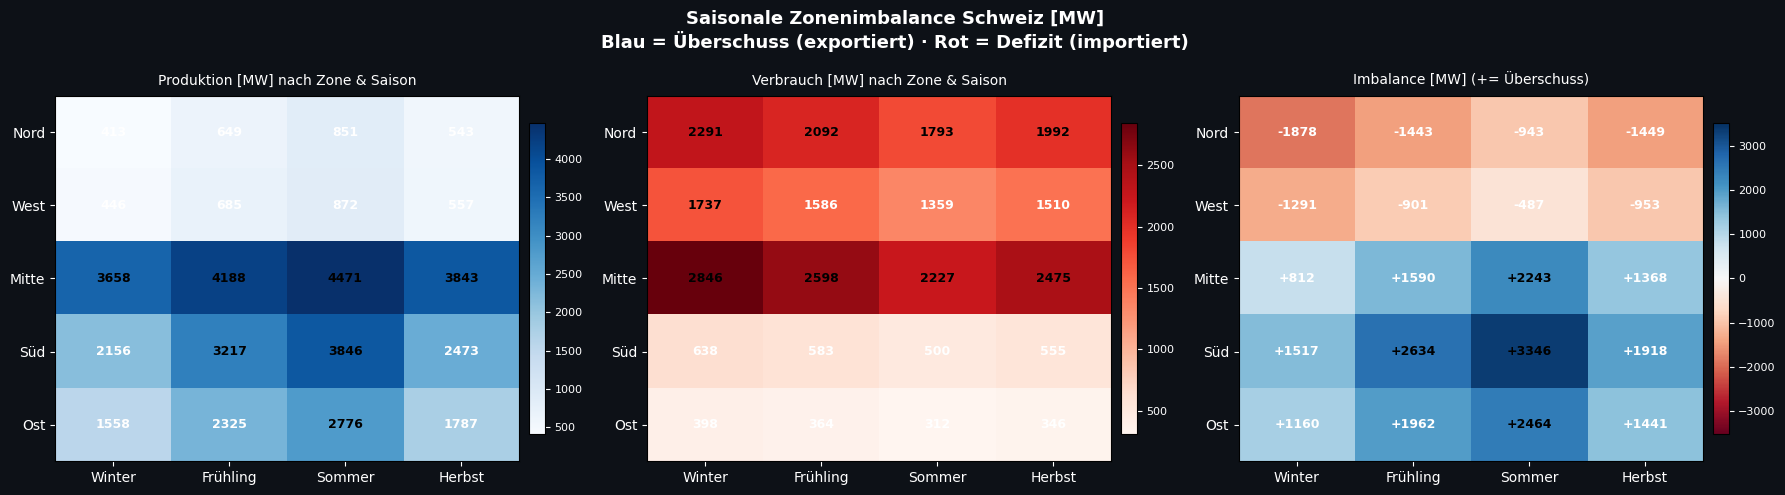

Chart 6a gespeichert: output\charts\realistisch\kuer_nb06_zonenimbalance_saisonal.png


In [25]:
# ── 6.2a Heatmap: Imbalance Zone × Saison ─────────────────────────────────────
import matplotlib.colors as mcolors

pivot_imb = df_sz.pivot(index='Zone', columns='Saison', values='Imbalance_MW')[SAISON_NAMES]
pivot_prod = df_sz.pivot(index='Zone', columns='Saison', values='Produktion_MW')[SAISON_NAMES]
pivot_verb = df_sz.pivot(index='Zone', columns='Saison', values='Verbrauch_MW')[SAISON_NAMES]

zones_ordered = ['Nord','West','Mitte','Süd','Ost']  # Nord/West oben (Defizit), Süd/Ost unten

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
fig.suptitle('Saisonale Zonenimbalance Schweiz [MW]\n'
             'Blau = Überschuss (exportiert) · Rot = Defizit (importiert)',
             color='white', fontsize=13, fontweight='bold')

for ax, (matrix_df, title, cmap) in zip(axes, [
    (pivot_prod.loc[zones_ordered],  'Produktion [MW] nach Zone & Saison',    'Blues'),
    (pivot_verb.loc[zones_ordered],  'Verbrauch [MW] nach Zone & Saison',     'Reds'),
    (pivot_imb.loc[zones_ordered],   'Imbalance [MW] (+= Überschuss)',         'RdBu'),
]):
    # Divergente Colormap für Imbalance, sequenziell für Prod/Verb
    if 'Imbalance' in title:
        vmax = abs(matrix_df.values).max() * 1.05
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(matrix_df.values, cmap=cmap, norm=norm, aspect='auto')
    else:
        im = ax.imshow(matrix_df.values, cmap=cmap, aspect='auto')

    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.85)
    cbar.ax.tick_params(colors='white', labelsize=8)
    cbar.ax.yaxis.label.set_color('white')

    ax.set_xticks(range(4))
    ax.set_xticklabels(SAISON_NAMES, color='white', fontsize=10)
    ax.set_yticks(range(len(zones_ordered)))
    ax.set_yticklabels(zones_ordered, color='white', fontsize=10)
    ax.set_title(title, color='white', pad=8, fontsize=10)

    # Werte annotieren
    for i in range(len(zones_ordered)):
        for j in range(4):
            val = matrix_df.values[i, j]
            col = 'white' if abs(val) < abs(matrix_df.values).max()*0.6 else 'black'
            ax.text(j, i, f'{val:+.0f}' if 'Imbalance' in title else f'{val:.0f}',
                    ha='center', va='center', color=col, fontsize=9, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_zonenimbalance_saisonal.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart 6a gespeichert: {p}')


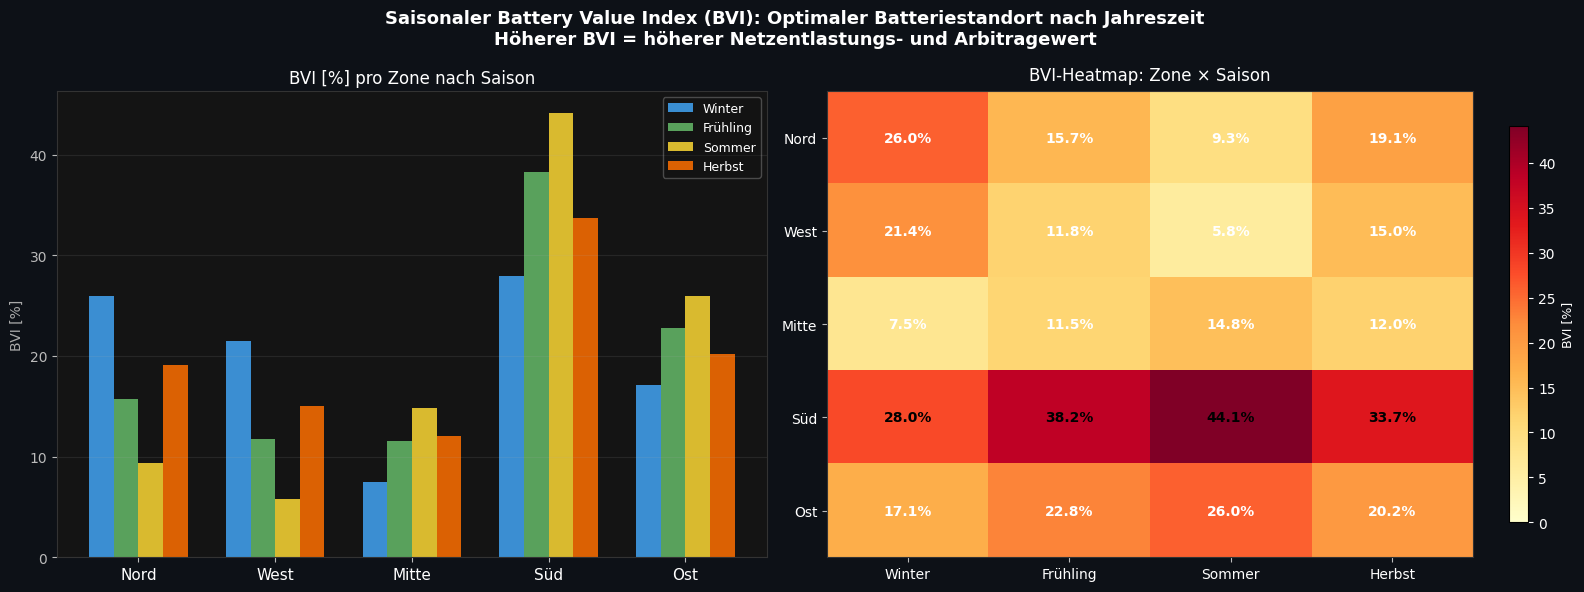

Chart 6b gespeichert: output\charts\realistisch\kuer_nb06_bvi_saisonal.png

Wichtigste Erkenntnisse:
  Nord  : Bester BVI im Winter     (26.0%) | Schwächster: Sommer (9.3%)
  West  : Bester BVI im Winter     (21.4%) | Schwächster: Sommer (5.8%)
  Mitte : Bester BVI im Sommer     (14.8%) | Schwächster: Winter (7.5%)
  Süd   : Bester BVI im Sommer     (44.1%) | Schwächster: Winter (28.0%)
  Ost   : Bester BVI im Sommer     (26.0%) | Schwächster: Winter (17.1%)


In [26]:
# ── 6.2b Saisonaler BVI: Wann & wo sind Batterien am wertvollsten? ─────────────
# BVI saisonal: Imbalance × Engpassmultiplikator (wie in Sektion 3, aber pro Saison)

ENGPASS_MULT = {'Nord':1.5, 'Mitte':1.0, 'West':1.8, 'Süd':2.0, 'Ost':1.6}
SAISON_COLORS_MAP = {'Winter':'#42A5F5','Frühling':'#66BB6A','Sommer':'#FDD835','Herbst':'#FF6F00'}

# BVI pro Zone × Saison berechnen
bvi_data = []
for saison in SAISON_NAMES:
    df_s = df_sz[df_sz['Saison']==saison].copy()
    df_s['BVI_raw'] = df_s['Imbalance_MW'].abs() * df_s['Zone'].map(ENGPASS_MULT)
    total = df_s['BVI_raw'].sum()
    df_s['BVI_pct'] = df_s['BVI_raw'] / total * 100 if total > 0 else 0
    bvi_data.append(df_s[['Zone','Saison','Imbalance_MW','BVI_pct']])

df_bvi_s = pd.concat(bvi_data, ignore_index=True)
pivot_bvi = df_bvi_s.pivot(index='Zone', columns='Saison', values='BVI_pct')[SAISON_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#141414')
    ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
fig.suptitle('Saisonaler Battery Value Index (BVI): Optimaler Batteriestandort nach Jahreszeit\n'
             'Höherer BVI = höherer Netzentlastungs- und Arbitragewert',
             color='white', fontsize=13, fontweight='bold')

# Panel 1: Gestapelter Balken Zone → Saison-BVI
ax = axes[0]
x = np.arange(len(zones_ordered))
w = 0.18
for j, saison in enumerate(SAISON_NAMES):
    vals = [pivot_bvi.loc[z, saison] if z in pivot_bvi.index else 0 for z in zones_ordered]
    ax.bar(x + (j-1.5)*w, vals, w, label=saison,
           color=SAISON_COLORS_MAP[saison], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(zones_ordered, color='white', fontsize=11)
ax.set_title('BVI [%] pro Zone nach Saison', color='white')
ax.set_ylabel('BVI [%]', color='#aaa')
ax.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.12)

# Panel 2: Heatmap BVI Zone × Saison
ax = axes[1]
bvi_matrix = np.array([[pivot_bvi.loc[z, s] if z in pivot_bvi.index else 0
                         for s in SAISON_NAMES] for z in zones_ordered])
im = ax.imshow(bvi_matrix, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=bvi_matrix.max())
cbar = plt.colorbar(im, ax=ax, fraction=0.04, shrink=0.85)
cbar.set_label('BVI [%]', color='white', fontsize=9)
cbar.ax.tick_params(colors='white')
ax.set_xticks(range(4))
ax.set_xticklabels(SAISON_NAMES, color='white', fontsize=10)
ax.set_yticks(range(len(zones_ordered)))
ax.set_yticklabels(zones_ordered, color='white', fontsize=10)
ax.set_title('BVI-Heatmap: Zone × Saison', color='white', pad=8)
for i, zone in enumerate(zones_ordered):
    for j, saison in enumerate(SAISON_NAMES):
        val = bvi_matrix[i, j]
        col = 'black' if val > bvi_matrix.max()*0.6 else 'white'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                color=col, fontsize=10, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_nb06_bvi_saisonal.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart 6b gespeichert: {p}')

# Wichtigste Erkenntnisse ausgeben
print('\nWichtigste Erkenntnisse:')
for zone in zones_ordered:
    if zone in pivot_bvi.index:
        row = pivot_bvi.loc[zone]
        best_s  = row.idxmax()
        worst_s = row.idxmin()
        print(f'  {zone:6}: Bester BVI im {best_s:<10} ({row[best_s]:.1f}%) | '
              f'Schwächster: {worst_s} ({row[worst_s]:.1f}%)')


**Einzelplot** (BVI-Heatmap saisonal für Bericht):

In [27]:
# ── Saisonaler BVI: Einzelplot Heatmap ────────────────────────────────────────
if 'df_bvi_s' in dir() and not df_bvi_s.empty:
    pivot_bvi_s = df_bvi_s.pivot(index='Zone', columns='Saison', values='BVI_pct')
    pivot_bvi_s = pivot_bvi_s[SAISON_NAMES]
    zones_ord   = ['Nord','West','Mitte','Süd','Ost']

    fig_zs, ax_zs = plt.subplots(figsize=(10, 5))
    fig_zs.patch.set_facecolor('#0d1117')
    ax_zs.set_facecolor('#0d1117'); ax_zs.tick_params(colors='white')

    bvi_mat = [[pivot_bvi_s.loc[z, s] if z in pivot_bvi_s.index else 0
                for s in SAISON_NAMES] for z in zones_ord]
    im_zs = ax_zs.imshow(bvi_mat, cmap='YlOrRd', aspect='auto',
                          vmin=0, vmax=max(max(r) for r in bvi_mat))
    cbar_zs = plt.colorbar(im_zs, ax=ax_zs, fraction=0.04, shrink=0.85)
    cbar_zs.set_label('BVI [%]', color='white', fontsize=9)
    cbar_zs.ax.tick_params(colors='white')

    ax_zs.set_xticks(range(4)); ax_zs.set_xticklabels(SAISON_NAMES, color='white', fontsize=11)
    ax_zs.set_yticks(range(5)); ax_zs.set_yticklabels(zones_ord, color='white', fontsize=11)
    ax_zs.set_title('Saisonaler Battery Value Index: Optimaler Standort nach Jahreszeit',
                    color='white', fontsize=12, fontweight='bold', pad=10)

    for i, zone in enumerate(zones_ord):
        for j, saison in enumerate(SAISON_NAMES):
            val = bvi_mat[i][j]
            col = 'black' if val > max(max(r) for r in bvi_mat)*0.55 else 'white'
            ax_zs.text(j, i, f'{val:.1f}%', ha='center', va='center',
                       color=col, fontsize=11, fontweight='bold')

    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, 'kuer_nb06_bvi_heatmap.png')
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'  Einzelplot: kuer_nb06_bvi_heatmap.png')
else:
    print('df_bvi_s nicht verfügbar – Sektion 6 zuerst ausführen.')


  Einzelplot: kuer_nb06_bvi_heatmap.png


---
### 6.3 Fazit: Saisonale Standortstrategie für Batteriespeicher

Die saisonale Analyse zeigt zwei wichtige Erkenntnisse, die den Jahresdurchschnitts-BVI ergänzen:

**1. Zonenimbalance ist stark saisonal:**
- **Süd/Ost im Sommer:** Massiver Überschuss durch Schneeschmelze + Speicherseen voll → BVI hoch (Puffern lohnt)
- **Süd/Ost im Winter:** Speicher leer, reduzierte Produktion → Überschuss schrumpft oder kippt
- **Nord/West konstant:** Ganzjährig Defizit, Winter stärker (Heizung) → BVI stabil hoch

**2. Arbitrage-Spread ist saisonal (→ NB03 Chart 5a):**
- **Frühling**: höchster Intraday-Spread (~139 EUR/MWh) — Duck-Curve-Effekt maximal (Solar bereits aktiv, Heizlast noch hoch)
- **Winter**: niedrigster Spread (~85 EUR/MWh) — entgegen intuitiver Erwartung
- **Sommer**: Negativpreise durch Solar → kostenlose Ladezyklen, aber geringerer Einspeiseerlös
- **Herbst**: Spread mittel (~120 EUR/MWh) — Übergangsphase

**Empfehlung für Investoren:**
Eine Batterie in **Nord/West** (Defizit-Zone) profitiert sowohl von ganzjährig hohem Arbitrage-Spread  
als auch von stabilen Import-Situationen — das ist die robusteste Strategie.  
Eine Batterie in **Süd/Ost** hingegen hat saisonale Peaks im Sommer, aber schwächere Winter.


---
| [← NB05 Business Strategy](05_Business_Strategy.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB07 Cross-Border](07_Cross_Border.ipynb) |
|:---|:---:|---:|
